In [1]:
# ==============================================================================
# 0. ENVIRONMENT SETUP
# ==============================================================================

# 1. Core Libraries and Data Manipulation
import os
import re
import gc
import joblib
import numpy as np
import pandas as pd
from collections import Counter

# 2. Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Indonesian Natural Language Processing (NLP)
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 4. Feature Extraction and Class Balancing (SMOTE)
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 5. Multinomial Naive Bayes and Cross-Validation
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import (
    StratifiedKFold, 
    GridSearchCV, 
    cross_val_score, 
    cross_val_predict
)

# 6. Model Evaluation Metrics
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# 7. Dataset Download Utility
import kagglehub

/home/burea00/Projects/ordinal-rating-classification-naive-bayes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Stage 1: Data Acquisition and Exploration

Dataset acquisition, stratified sampling, label distribution analysis, class imbalance assessment, and preliminary data quality verification.

In [2]:
# ==============================================================================
# TAHAP 1: DATA ACQUISITION AND EXPLORATION
# ==============================================================================

# --- 1.1 Download Dataset from Kaggle ---
# Download the Tokopedia product review dataset using the KaggleHub API.
path = kagglehub.dataset_download('farhan999/tokopedia-product-reviews')
print('Dataset Directory:', path)

# --- 1.2 Verify Dataset Structure ---
# List all CSV files in the downloaded directory to verify that the dataset
# has been successfully retrieved.
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Dataset Directory: /home/burea00/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2
/home/burea00/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2/tokopedia-product-reviews-2019.csv


## Load and Inspect the Dataset

Load the dataset into a Pandas DataFrame and inspect its structure to identify the review text and rating label columns.

In [3]:
# --- 1.3 Pembacaan Data dan Konfigurasi Display ---

# Mengatur tampilan output Pandas agar data ulasan tidak terpotong saat inspeksi manual
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Mendefinisikan lokasi file CSV hasil unduhan
csv_file_path = os.path.join(path, 'tokopedia-product-reviews-2019.csv')

# Memuat dataset ke dalam DataFrame Pandas dengan pengecekan keberadaan file
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully. Total records: {len(df)}")
    display(df.head())
else:
    print(f"Error: File not found at {csv_file_path}")

Dataset loaded successfully. Total records: 40607


,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staples-dekorasi-staples-kayu-refill-8mm-staples-gun-4-8...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; OSSEL 1022J,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-staples-tembak-air-nailer-gun-ossel-1022j
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gun Max t3-10 mb MAX,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-refill-staples-jok-kulit-motor-staple-gun-max-t3-10-m...


In [4]:
# --- 1.4 Inspect Dataset Structure and Data Quality ---

# Display dataset information, including data types and memory usage.
print("=== DATASET STRUCTURE ===")
df.info()

# Check for missing values in each column to ensure data integrity
# before proceeding with preprocessing.
print("\n=== MISSING VALUE ANALYSIS ===")
print(df.isnull().sum())

=== DATASET STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB

=== MISSING VALUE ANALYSIS ===
Unnamed: 0       0
text             0
rating           0
category         0
product_name     0
product_id       0
sold            14
shop_id          0
product_url      0
dtype: int64


In [5]:
# --- 1.5 Report Dataset Size ---

# Display the total number of reviews in the original dataset.
total_reviews = len(df)
print(f"Total number of reviews: {total_reviews}")

Total number of reviews: 40607


## Duplicate Review Detection and Removal

Identify and remove duplicate reviews to reduce redundancy and minimize potential bias during model training.

In [6]:
# --- 1.6 Remove Duplicate Reviews ---

# Record the initial number of reviews before deduplication.
initial_count = len(df)

# Remove duplicate reviews based on identical review text.
# Duplicate entries may introduce bias by artificially increasing the
# frequency of specific words during model training.
df = df.drop_duplicates(subset="text")

# Display the deduplication summary.
print(f"Duplicate reviews removed : {initial_count - len(df)}")
print(f"Remaining unique reviews  : {len(df)}")

Duplicate reviews removed : 3306
Remaining unique reviews  : 37301


## Initial Rating Distribution

Analyze the distribution of the original dataset before stratified sampling. This provides the baseline class frequencies and reveals the degree of class imbalance across the five rating levels.

In [7]:
# --- 1.7 Analyze Initial Rating Distribution ---

# Count the number of reviews for each rating class (1–5).
rating_counts = df["rating"].value_counts().sort_index()

# Calculate the percentage of each rating class.
rating_percentages = (
    df["rating"].value_counts(normalize=True).sort_index() * 100
)

# Combine the results into a summary table.
rating_distribution = pd.DataFrame({
    "Count": rating_counts,
    "Percentage (%)": rating_percentages.round(2),
})

print("=== INITIAL RATING DISTRIBUTION ===")
display(rating_distribution)

=== INITIAL RATING DISTRIBUTION ===


,Count,Percentage (%)
rating,,
1,531,1.42
2,380,1.02
3,1762,4.72
4,6995,18.75
5,27633,74.08


## Feature Selection & Class Distribution Visualization

<h4>Select the relevant features for modeling and visualize the rating distribution to identify class imbalance.</h4>

In [8]:
# --- 1.8 Feature Selection and Dataset Preparation ---

# Display the number of columns before feature selection
print(f"Number of columns before selection: {len(df.columns)}")

# Keep only the review text and rating columns
df_sample = df[['text', 'rating']].copy()

# Reset the index after preprocessing
df_sample = df_sample.reset_index(drop=True)

print(f"Number of columns after selection: {len(df_sample.columns)}")
print("\n=== FINAL DATASET FOR PREPROCESSING ===")
display(df_sample.head())

Number of columns before selection: 9
Number of columns after selection: 2

=== FINAL DATASET FOR PREPROCESSING ===


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5
2,Paket rapi...mantap....cepat....sampe ke tujuan,5
3,ya saya puas dgn barangnya,5
4,Responya luar biasa b mantap,5


=== ORDINAL RATING DISTRIBUTION ===


,Rating,Count,Percentage
0,1,531,1.42
1,2,380,1.02
2,3,1762,4.72
3,4,6995,18.75
4,5,27633,74.08


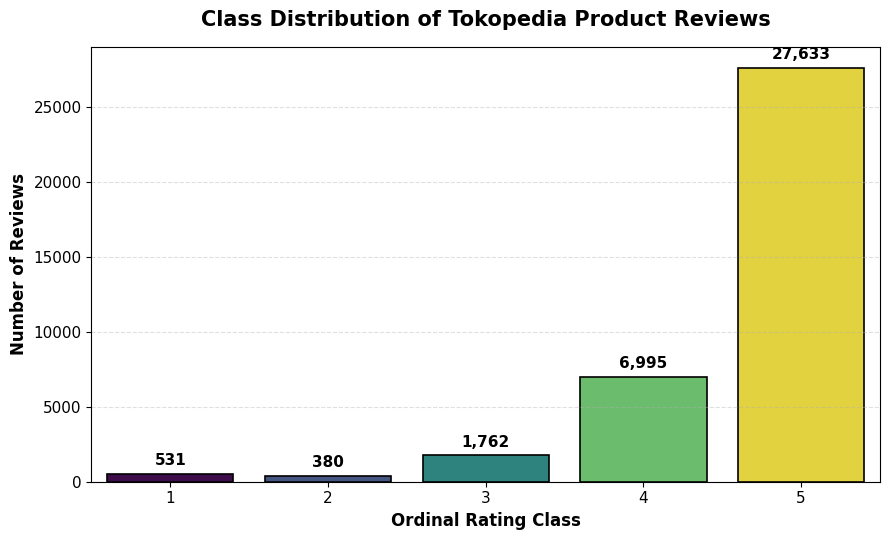


CLASS DISTRIBUTION SUMMARY
- Majority class: Rating 5 (74.08%).
- Minority class: Rating 2 (1.02%).
- Imbalance ratio: 72.72:1 (majority vs. minority class).


In [9]:
# --- 1.9 Class Distribution Analysis (Class Imbalance Detection) ---

# Compute the class distribution
dist_df = df_sample['rating'].value_counts().reset_index()
dist_df.columns = ['Rating', 'Count']

# Sort ratings in ascending ordinal order
dist_df = dist_df.sort_values('Rating').reset_index(drop=True)
dist_df['Percentage'] = (dist_df['Count'] / len(df_sample)) * 100

print("=== ORDINAL RATING DISTRIBUTION ===")
display(dist_df.round(2))

# Visualize the class distribution
plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    x='Rating',
    y='Count',
    data=dist_df,
    hue='Rating',
    palette='viridis',
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

plt.title(
    'Class Distribution of Tokopedia Product Reviews',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Ordinal Rating Class',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Number of Reviews',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='both', labelsize=11)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=4, fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Generate a brief summary
majority_class = dist_df.loc[dist_df['Count'].idxmax()]
minority_class = dist_df.loc[dist_df['Count'].idxmin()]
imbalance_ratio = majority_class['Count'] / minority_class['Count']

print("\n" + "=" * 75)
print("CLASS DISTRIBUTION SUMMARY")
print("=" * 75)
print(
    f"- Majority class: Rating {int(majority_class['Rating'])} "
    f"({majority_class['Percentage']:.2f}%)."
)
print(
    f"- Minority class: Rating {int(minority_class['Rating'])} "
    f"({minority_class['Percentage']:.2f}%)."
)
print(
    f"- Imbalance ratio: {imbalance_ratio:.2f}:1 "
    f"(majority vs. minority class)."
)
print("=" * 75)

In [10]:
# --- 1.10 Export Cleaned Dataset and Validate Data Integrity ---

# Export the cleaned dataset as a reproducible checkpoint
df_sample.to_csv('../data/raw/data_sample.csv', index=False)
print("Dataset successfully saved to 'data/raw/data_sample.csv'.")

# Reload the dataset to verify that it was saved correctly
print("Reloading the dataset for validation...")
df_sample = pd.read_csv('../data/raw/data_sample.csv')

# Remove rows with missing values in the required columns
initial_len = len(df_sample)
df_sample = df_sample.dropna(subset=['text', 'rating'])

# Ensure the review text is stored as string
df_sample['text'] = df_sample['text'].astype(str)

# Display validation summary
if len(df_sample) != initial_len:
    print(f"{initial_len - len(df_sample)} rows containing missing values were removed.")
else:
    print("Data integrity check passed. No missing values were found.")

print(f"Total samples ready for preprocessing: {len(df_sample)}")
display(df_sample.head())

Dataset successfully saved to 'data/raw/data_sample.csv'.
Reloading the dataset for validation...
Data integrity check passed. No missing values were found.
Total samples ready for preprocessing: 37301


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5
2,Paket rapi...mantap....cepat....sampe ke tujuan,5
3,ya saya puas dgn barangnya,5
4,Responya luar biasa b mantap,5


# Stage 2: Text Preprocessing & Feature Engineering





## A. Text Preprocessing

### 1. Slang Word Identification

In [11]:
# ==============================================================================
# STAGE 2: TEXT PREPROCESSING
# ==============================================================================

# Load the cleaned dataset generated in Stage 1
try:
    df_sample = pd.read_csv('../data/raw/data_sample.csv')
    print(f"Dataset successfully loaded. Total samples: {len(df_sample)}")
except FileNotFoundError:
    print("Error: 'data/raw/data_sample.csv' was not found. Please run Stage 1 first.")

# --- 2.1 Slang Word Identification (Exploratory Analysis) ---

def light_text_cleaning(text):
    """
    Apply lightweight text cleaning for word frequency analysis.
    """
    # Convert text to lowercase
    text = str(text).lower()

    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    return re.sub(r'\s+', ' ', text).strip()

# Apply lightweight cleaning
print("Processing review texts and computing word frequencies...")
all_text_sample = df_sample['text'].apply(light_text_cleaning)

# Build a corpus containing all words
all_words = ' '.join(all_text_sample).split()

# Count word frequencies
word_counts = Counter(all_words)

# Store the 500 most frequent words
df_top_500 = pd.DataFrame(
    word_counts.most_common(500),
    columns=['Word', 'Frequency']
)

print("--- TOP 500 WORD FREQUENCY ANALYSIS FOR SLANG DICTIONARY CONSTRUCTION ---")

# Display the results in batches for manual inspection
for i in range(0, 500, 50):
    print(f"\n>>> Rank {i + 1} to {i + 50} <<<")
    display(df_top_500.iloc[i:i + 50])
    print("-" * 50)

Dataset successfully loaded. Total samples: 37301
Processing review texts and computing word frequencies...
--- TOP 500 WORD FREQUENCY ANALYSIS FOR SLANG DICTIONARY CONSTRUCTION ---

>>> Rank 1 to 50 <<<


,Word,Frequency
0,barang,14242
1,sesuai,10483
2,cepat,8305
3,dan,7612
4,bagus,7163
5,dengan,5108
6,sudah,5023
7,sampai,4244
8,pengiriman,4235
9,baik,4110


--------------------------------------------------

>>> Rank 51 to 100 <<<


,Word,Frequency
50,sdh,1167
51,ini,1115
52,bisa,1027
53,sukses,911
54,udah,900
55,sampe,893
56,tp,839
57,untuk,830
58,thx,805
59,cepet,804


--------------------------------------------------

>>> Rank 101 to 150 <<<


...

--------------------------------------------------

>>> Rank 401 to 450 <<<


,Word,Frequency
400,karna,79
401,segitu,79
402,bro,79
403,model,79
404,on,79
405,beberapa,78
406,om,78
407,bonus,78
408,tgl,78
409,nyesel,78


--------------------------------------------------

>>> Rank 451 to 500 <<<


,Word,Frequency
450,flash,68
451,pertama,67
452,i,67
453,jika,67
454,bermanfaat,66
455,buka,66
456,for,66
457,aku,66
458,prosesnya,66
459,panjang,66


--------------------------------------------------


### 2. Build a Custom Slang Dictionary (Frequency-Based)

In [12]:
# --- 2.2 Build a Custom Slang Dictionary ---

# Manually curated slang dictionary based on the frequency analysis.
slang_data = {
    'slang': [
        # 1. Negations, Conjunctions, and Common Expressions (43 entries)
        'ga', 'gak', 'gk', 'ngga', 'nggak', 'g', 'tdk',
        'blm', 'belom',
        'sdh', 'udah', 'dah', 'uda', 'smp', 'sampe', 'smpe', 'nyampe',
        'dgn', 'dg', 'jg', 'utk', 'tp', 'tpi', 'kalo', 'klo', 'krn', 'karna',
        'd', 'n', 'deh', 'aja', 'sih', 'biar', 'jd', 'lg', 'cuman', 'cuma',
        'nih', 'yah', 'yaa', 'yaaa', 'yaaaa', 'gpp',
        
        # 2. E-Commerce Terms, Logistics, and Seller References (35 entries)
        'brg', 'brgnya', 'brng', 'barangnya', 'produknya', 'product', 'item',
        'paking', 'packaging', 'packingnya', 'pakingnya', 'kemasan', 'kemasannya', 'rapih',
        'seler', 'sellernya', 'tokonya', 'pelapak', 'penjualnya',
        'pesen', 'pesenan', 'orderan', 'dipesan', 'order',
        'rekomen', 'recomended', 'recomend', 'rekomended', 'ori',
        'bos', 'boss', 'agan', 'kurir', 'paketnya',
        
        # 3. Descriptive Words and Common Expressions (26 entries)
        'cepet', 'cpt', 'fast',
        'baguss', 'bagusss', 'bgs', 'bgus',
        'mantab', 'mantapp', 'mantappp', 'mantul', 'mantep', 'top',
        'ok', 'oke', 'sip', 'sipp',
        'murah', 'agak', 'lama', 'bgt', 'kurang', 'keren', 'tebal', 'mulus', 'dikit', 'gampang',
        
        # 4. Thank-You Expressions (12 entries)
        'trims', 'tq', 'tks', 'trimakasih', 'trima', 'mksh', 'thank', 'thankyou', 'makasih', 'thanks', 'terimakasih', 'thx'
    ],
    'formal': [
        # 1. Standard Forms: Negations, Conjunctions, and Common Expressions
        'tidak', 'tidak', 'tidak', 'tidak', 'tidak', 'tidak', 'tidak',
        'belum', 'belum',
        'sudah', 'sudah', 'sudah', 'sudah', 'sampai', 'sampai', 'sampai', 'sampai',
        'dengan', 'dengan', 'juga', 'untuk', 'tapi', 'tapi', 'kalau', 'kalau', 'karena', 'karena',
        'di', 'dan', 'deh', 'saja', 'sih', 'biar', 'jadi', 'lagi', 'cuma', 'cuma',
        'nih', 'ya', 'ya', 'ya', 'ya', 'tidak apa-apa',
        
        # 2. Standard Forms: E-Commerce Terms
        'barang', 'barang', 'barang', 'barang', 'produk', 'produk', 'barang',
        'packing', 'packing', 'packing', 'packing', 'packing', 'packing', 'rapi',
        'seller', 'seller', 'toko', 'seller', 'seller',
        'pesan', 'pesanan', 'pesanan', 'pesan', 'pesan',
        'recommended', 'recommended', 'recommended', 'recommended', 'original',
        'bos', 'bos', 'agan', 'kurir', 'paket',
        
        # 3. Standard Forms: Descriptive Words
        'cepat', 'cepat', 'cepat',
        'bagus', 'bagus', 'bagus', 'bagus',
        'mantap', 'mantap', 'mantap', 'mantap', 'mantap', 'mantap',
        'oke', 'oke', 'oke', 'oke',
        'murah', 'agak', 'lama', 'banget', 'kurang', 'keren', 'tebal', 'mulus', 'sedikit', 'mudah',
        
        # 4. Standard Forms: Thank-You Expressions
        'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih'
    ]
}

# --- 2.3 Validate, Save, and Initialize the Dictionary ---

# Ensure that the slang and formal word lists have the same length
if len(slang_data['slang']) != len(slang_data['formal']):
    print(f"FATAL ERROR: Dictionary size mismatch. Slang entries: {len(slang_data['slang'])}, Formal entries: {len(slang_data['formal'])}")
else:
    # Save the dictionary for documentation and reproducibility
    pd.DataFrame(slang_data).to_csv('../data/raw/custom_slang_dictionary.csv', index=False)
    
    # Reload and normalize the dictionary
    df_slang_load = pd.read_csv('../data/raw/custom_slang_dictionary.csv')
    df_slang_load['slang'] = df_slang_load['slang'].astype(str).str.strip().str.lower()
    df_slang_load['formal'] = df_slang_load['formal'].astype(str).str.strip().str.lower()
    
    # Remove multi-word slang expressions
    df_slang_load = df_slang_load[~df_slang_load['slang'].str.contains(r'\s+')]
    
    # Convert the DataFrame into a dictionary for faster lookup
    SLANG_DICT = dict(zip(df_slang_load['slang'], df_slang_load['formal']))
    print(f"Custom slang dictionary initialized successfully "
          f"({len(SLANG_DICT)} unique entries)."
        )

# --- 2.4 Load the Public Indonesian Slang Dictionary (Kaggle) ---

print("Loading the public Indonesian slang dictionary...")

# Checking file
if not os.path.exists('../data/raw/slang_indo.xls'):
    print("FATAL ERROR: File 'data/raw/slang_indo.xls' was not found.")
else:
    # Load the public slang dictionary used as the baseline.
    df_slang_publik = pd.read_csv('../data/raw/slang_indo.xls', header=None, names=['slang', 'formal'])

    # Normalize dictionary entries
    df_slang_publik['slang'] = df_slang_publik['slang'].astype(str).str.strip().str.lower()
    df_slang_publik['formal'] = df_slang_publik['formal'].astype(str).str.strip().str.lower()

    # Remove missing entries
    df_slang_publik = df_slang_publik.dropna()

    # Convert into a Python dictionary
    SLANG_DICT_PUBLIC = dict(zip(df_slang_publik['slang'], df_slang_publik['formal']))

    print(
        f"Public slang dictionary loaded successfully "
        f"({len(SLANG_DICT_PUBLIC)} unique entries)."
    )

# --- 2.5 Build the Hybrid Slang Dictionary ---

"""
Construct the final hybrid slang dictionary by combining the public
Kaggle dictionary with the custom frequency-based dictionary.

When duplicate entries exist, the custom dictionary overrides the
public dictionary to preserve domain-specific e-commerce terminology.
"""

SLANG_DICT_HYBRID = {
    **SLANG_DICT_PUBLIC,
    **SLANG_DICT
}

print(
    f"Hybrid slang dictionary initialized successfully "
    f"({len(SLANG_DICT_HYBRID)} entries)."
)

Custom slang dictionary initialized successfully (116 unique entries).
Loading the public Indonesian slang dictionary...
Public slang dictionary loaded successfully (1250 unique entries).
Hybrid slang dictionary initialized successfully (1320 entries).


### 3. Apply Text Preprocessing

In [13]:
# --- 2.6 Text Preprocessing Functions (Four Variants) ---

# Preserve sentiment-bearing words that should not be removed during stopword filtering.
important_keep = {
    'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang',
    'tapi', 'cuma', 'namun', 'walau', 'meski', 'padahal', 'cuman',
    'banget', 'sangat', 'sekali', 'agak', 'lumayan', 'super', 'paling'
}

try:
    stop_words = set(stopwords.words("indonesian"))
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("indonesian"))

# Remove protected words from the default Indonesian stopword list.
stop_words = stop_words - important_keep

# Precompiled regular expressions for faster text processing.
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HTML_PATTERN = re.compile(r'<.*?>|&([a-z0-9]+|#[0-9]{1,6});')
NON_ALPHA_PATTERN = re.compile(r'[^a-z\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')

# Variant 1: Custom Slang Dictionary
def preprocessing_with_slang(text):
    """
    Applies text cleaning, custom slang normalization,
    and stopword filtering.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()

    # Normalize tokens using the custom slang dictionary.
    normalized_words = [SLANG_DICT.get(word, word) for word in words]

    # Remove stopwords while preserving meaningful sentiment words.
    final_words = [
        word for word in normalized_words
        if word not in stop_words and len(word) > 1
    ]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

# Variant 2: No Slang Normalization
def preprocessing_without_slang(text):
    """
    Applies text cleaning and stopword filtering
    without slang normalization.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()

    final_words = [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

# Variant 3: Kaggle Slang Dictionary
def preprocessing_kaggle_slang(text):
    """
    Applies text cleaning using the public Kaggle
    Indonesian slang dictionary.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()

    # Normalize tokens using the Kaggle slang dictionary.
    normalized_words = [SLANG_DICT_PUBLIC.get(word, word) for word in words]

    final_words = [
        word for word in normalized_words
        if word not in stop_words and len(word) > 1
    ]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

## Variant 4: Hybrid Slang Dictionary
def preprocessing_hybrid_slang(text):
    """
    Applies text cleaning using the hybrid slang
    dictionary (Kaggle + Custom).
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()

    # Normalize tokens using the hybrid dictionary.
    normalized_words = [SLANG_DICT_HYBRID.get(word, word) for word in words]

    final_words = [
        word for word in normalized_words
        if word not in stop_words and len(word) > 1
    ]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

print("Text preprocessing functions initialized successfully.")

Text preprocessing functions initialized successfully.


In [14]:
# --- 2.7 Apply Preprocessing to the Dataset ---

print("Applying Variant 1 (Custom Slang Dictionary)...")
df_sample["text_clean_WITH_slang"] = df_sample["text"].apply(preprocessing_with_slang)

print("Applying Variant 2 (No Slang Normalization)...")
df_sample["text_clean_NO_slang"] = df_sample["text"].apply(preprocessing_without_slang)

print("Applying Variant 3 (Kaggle Slang Dictionary)...")
df_sample["text_clean_KAGGLE_slang"] = df_sample["text"].apply(preprocessing_kaggle_slang)

print("Applying Variant 4 (Hybrid Slang Dictionary)...")
df_sample["text_clean_HYBRID_slang"] = df_sample["text"].apply(preprocessing_hybrid_slang)

print("All preprocessing variants completed.\n")

# --- 2.8 Verify Preprocessing Results ---

pd.set_option("display.max_colwidth", 120)

print(
    "=== COMPARISON: CUSTOM vs NO SLANG vs KAGGLE vs HYBRID SLANG NORMALIZATION ==="
)

# Display several reviews containing slang terms for qualitative comparison.
sample_check = (
    df_sample[
        df_sample["text"].str.contains("brg|yg|gan|gak|udh", case=False, na=False)
    ]
    .head(5)
)

display(
    sample_check[
        [
            "text",
            "text_clean_WITH_slang",
            "text_clean_NO_slang",
            "text_clean_KAGGLE_slang",
            "text_clean_HYBRID_slang",
        ]
    ]
)

# --- 2.9 Post-Processing Data Integrity Check ---

empty_with_slang = (df_sample["text_clean_WITH_slang"] == "").sum()
empty_no_slang = (df_sample["text_clean_NO_slang"] == "").sum()
empty_kaggle_slang = (df_sample["text_clean_KAGGLE_slang"] == "").sum()
empty_hybrid_slang = (df_sample["text_clean_HYBRID_slang"] == "").sum()

print("\nData Integrity Check:")
print(f"- Empty rows (Custom Slang): {empty_with_slang}")
print(f"- Empty rows (No Slang): {empty_no_slang}")
print(f"- Empty rows (Kaggle Slang): {empty_kaggle_slang}")
print(f"- Empty rows (Hybrid Slang): {empty_hybrid_slang}")

Applying Variant 1 (Custom Slang Dictionary)...
Applying Variant 2 (No Slang Normalization)...
Applying Variant 3 (Kaggle Slang Dictionary)...
Applying Variant 4 (Hybrid Slang Dictionary)...
All preprocessing variants completed.

=== COMPARISON: CUSTOM vs NO SLANG vs KAGGLE vs HYBRID SLANG NORMALIZATION ===


,text,text_clean_WITH_slang,text_clean_NO_slang,text_clean_KAGGLE_slang,text_clean_HYBRID_slang
7,Produk sesuai dengan spec di web dan respon seller sangat cepat. Thankyou.,produk sesuai spec web respon seller sangat cepat terima kasih,produk sesuai spec web respon seller sangat cepat thankyou,produk sesuai spec web respon seller sangat cepat thankyou,produk sesuai spec web respon seller sangat cepat terima kasih
8,"Respon super cepat, pengiriman cepat, Barang bagus sesuai deskripsi penjual..thx gan",respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual terima kasih gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual thx gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual terima kasih gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual terima kasih gan
11,Sayang produk yg datang di paking kurang rapi sehingga kebuka n isinya terhambur. Saran klo mengirimkan isi paku te...,sayang produk yg packing kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan paku...,sayang produk yg paking kurang rapi kebuka isinya terhambur saran klo mengirimkan isi paku tembak lakban dikemasan p...,sayang produk paking kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan pakunya ...,sayang produk packing kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan pakunya...
15,josss pokok e bisa buat langganan,joss pokok langganan,joss pokok langganan,joss pokok langganan,joss pokok langganan
16,"berfungsi dengan baik, normal",berfungsi normal,berfungsi normal,berfungsi normal,berfungsi normal



Data Integrity Check:
- Empty rows (Custom Slang): 153
- Empty rows (No Slang): 150
- Empty rows (Kaggle Slang): 154
- Empty rows (Hybrid Slang): 154


In [15]:
# --- 2.10 Final Data Validation ---

initial_len = len(df_sample)
print(f"Initial number of samples: {initial_len}")

# Replace empty strings with NaN in all preprocessing variants.
df_sample["text_clean_WITH_slang"] = df_sample["text_clean_WITH_slang"].replace("", np.nan)
df_sample["text_clean_NO_slang"] = df_sample["text_clean_NO_slang"].replace("", np.nan)
df_sample["text_clean_KAGGLE_slang"] = df_sample["text_clean_KAGGLE_slang"].replace("", np.nan)
df_sample["text_clean_HYBRID_slang"] = df_sample["text_clean_HYBRID_slang"].replace("", np.nan)

# Remove samples containing missing values in any preprocessing variant.
df_sample = df_sample.dropna(
    subset=[
        "text_clean_WITH_slang",
        "text_clean_NO_slang",
        "text_clean_KAGGLE_slang",
        "text_clean_HYBRID_slang",
    ]
).reset_index(drop=True)

print(f"Valid samples: {len(df_sample)}")
print(f"Removed samples: {initial_len - len(df_sample)}")

Initial number of samples: 37301
Valid samples: 37146
Removed samples: 155


### 5. Tokenization

In [16]:
# --- 2.11 Tokenization ---

print("Applying Variant 1 (Custom Slang)...")
df_sample["tokens_WITH_slang"] = df_sample["text_clean_WITH_slang"].str.split()

print("Applying Variant 2 (No Slang)...")
df_sample["tokens_NO_slang"] = df_sample["text_clean_NO_slang"].str.split()

print("Applying Variant 3 (Kaggle Slang)...")
df_sample["tokens_KAGGLE_slang"] = df_sample["text_clean_KAGGLE_slang"].str.split()

print("Applying Variant 4 (Hybrid Slang)...")
df_sample["tokens_HYBRID_slang"] = df_sample["text_clean_HYBRID_slang"].str.split()

print("\nTokenization completed.")

display(
    df_sample[
        [
            "text_clean_WITH_slang",
            "tokens_WITH_slang",
            "text_clean_NO_slang",
            "tokens_NO_slang",
            "text_clean_KAGGLE_slang",
            "tokens_KAGGLE_slang",
            "text_clean_HYBRID_slang",
            "tokens_HYBRID_slang",
        ]
    ].head(3)
)

Applying Variant 1 (Custom Slang)...
Applying Variant 2 (No Slang)...
Applying Variant 3 (Kaggle Slang)...
Applying Variant 4 (Hybrid Slang)...

Tokenization completed.


,text_clean_WITH_slang,tokens_WITH_slang,text_clean_NO_slang,tokens_NO_slang,text_clean_KAGGLE_slang,tokens_KAGGLE_slang,text_clean_HYBRID_slang,tokens_HYBRID_slang
0,barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]"
1,barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]"
2,paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]",paket rapi mantap cepat sampe tujuan,"[paket, rapi, mantap, cepat, sampe, tujuan]",paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]",paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]"


### 6. Stemming (Sastrawi)

In [17]:
# --- 2.13 Dictionary-Based Stemming (4 Parallel Variants) ---

# Initialize the Sastrawi stemmer.
factory = StemmerFactory()
stemmer = factory.create_stemmer()


def build_stemming_dictionary(tokens_series, label):
    """
    Builds a stemming dictionary from the unique vocabulary of a tokenized corpus.
    """
    print(f"\nCollecting unique vocabulary ({label})...")

    all_tokens = [word for tokens in tokens_series for word in tokens]
    unique_tokens = sorted(set(all_tokens))

    print(f"Total unique words ({label}): {len(unique_tokens):,}")

    stemmed_dict = {}

    print(f"Building stemming dictionary ({label})...")
    for i, word in enumerate(unique_tokens, start=1):
        stemmed_dict[word] = stemmer.stem(word)

        if i % 1000 == 0:
            print(f"  Progress: {i:,}/{len(unique_tokens):,}")

    print(f"Completed. Total entries: {len(stemmed_dict):,}")

    return unique_tokens, stemmed_dict


def apply_stemming(tokens, stemmed_dict):
    """
    Applies dictionary-based stemming to a token list.
    """
    return [stemmed_dict[word] for word in tokens]


variants = {
    "WITH Slang": "WITH",
    "WITHOUT Slang": "NO",
    "Kaggle Slang": "KAGGLE",
    "Hybrid Slang": "HYBRID",
}

unique_vocab = {}

for label, suffix in variants.items():

    token_col = f"tokens_{suffix}_slang"

    unique_tokens, stemmed_dict = build_stemming_dictionary(
        df_sample[token_col],
        label,
    )

    unique_vocab[suffix] = len(unique_tokens)

    print(f"Applying stemming ({label})...")

    df_sample[f"stemmed_list_{suffix}_slang"] = (
        df_sample[token_col]
        .apply(lambda tokens, d=stemmed_dict: apply_stemming(tokens, d))
    )
    
    del stemmed_dict
    gc.collect()


# --- 2.14 Text Reconstruction (Detokenization) ---

for suffix in ["WITH", "NO", "KAGGLE", "HYBRID"]:
    df_sample[f"text_final_{suffix}_slang"] = (
        df_sample[f"stemmed_list_{suffix}_slang"]
        .str.join(" ")
    )


print("\n=== VOCABULARY REDUCTION ANALYSIS ===")
print("Unique vocabulary before stemming:")
print(f"  - WITH Slang      : {unique_vocab['WITH']:,}")
print(f"  - WITHOUT Slang   : {unique_vocab['NO']:,}")
print(f"  - Kaggle Slang    : {unique_vocab['KAGGLE']:,}")
print(f"  - Hybrid Slang    : {unique_vocab['HYBRID']:,}")
print(
    f"  - Vocabulary Reduction: "
    f"{unique_vocab['NO'] - unique_vocab['WITH']:,} words"
)

print("\n=== FINAL PREPROCESSING OUTPUT ===")

display(
    df_sample[
        [
            "text_clean_WITH_slang",
            "text_final_WITH_slang",
            "text_clean_NO_slang",
            "text_final_NO_slang",
            "text_clean_KAGGLE_slang",
            "text_final_KAGGLE_slang",
            "text_clean_HYBRID_slang",
            "text_final_HYBRID_slang",
        ]
    ].head(3)
)

gc.collect()
print("\nMemory cleanup completed.")


Total unique words (WITH Slang): 12,477
Building stemming dictionary (WITH Slang)...
  Progress: 1,000/12,477
  Progress: 2,000/12,477
  Progress: 3,000/12,477
  Progress: 4,000/12,477
  Progress: 5,000/12,477
  Progress: 6,000/12,477
  Progress: 7,000/12,477
  Progress: 8,000/12,477
  Progress: 9,000/12,477
  Progress: 10,000/12,477
  Progress: 11,000/12,477
  Progress: 12,000/12,477
Completed. Total entries: 12,477
Applying stemming (WITH Slang)...

Total unique words (WITHOUT Slang): 12,569
Building stemming dictionary (WITHOUT Slang)...
  Progress: 1,000/12,569
  Progress: 2,000/12,569
  Progress: 3,000/12,569
  Progress: 4,000/12,569
  Progress: 5,000/12,569
  Progress: 6,000/12,569
  Progress: 7,000/12,569
  Progress: 8,000/12,569
  Progress: 9,000/12,569
  Progress: 10,000/12,569
  Progress: 11,000/12,569
  Progress: 12,000/12,569
Completed. Total entries: 12,569
Applying stemming (WITHOUT Slang)...

Total unique words (Kaggle Slang): 12,043
Building stemming dictionary (Kaggle

,text_clean_WITH_slang,text_final_WITH_slang,text_clean_NO_slang,text_final_NO_slang,text_clean_KAGGLE_slang,text_final_KAGGLE_slang,text_clean_HYBRID_slang,text_final_HYBRID_slang
0,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat
1,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah
2,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju,paket rapi mantap cepat sampe tujuan,paket rapi mantap cepat sampe tuju,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju



Memory cleanup completed.


In [18]:
# --- 2.15 Export Preprocessed Datasets ---

# Base columns retained in every exported dataset.
columns_base = ["text", "rating"]

# Mapping between preprocessing variants and output filenames.
variants = {
    "WITH": "../data/processed/data_WITH_slang_normalization.csv",
    "NO": "../data/processed/data_NO_slang_normalization.csv",
    "KAGGLE": "../data/processed/data_KAGGLE_slang_normalization.csv",
    "HYBRID": "../data/processed/data_HYBRID_slang_normalization.csv",
}


for suffix, output_path in variants.items():

    df_export = (
        df_sample[
            columns_base +
            [f"text_final_{suffix}_slang"]
        ]
        .rename(
            columns={
                f"text_final_{suffix}_slang": "text_final",
            }
        )
        .copy()
    )

    # Remove empty or missing rows.
    df_export = (
        df_export[df_export["text_final"].str.strip() != ""]
        .dropna(subset=["text_final"])
        .reset_index(drop=True)
    )

    df_export.to_csv(output_path, index=False)

    print(f"\nDataset: {suffix}")
    print(f"File      : {output_path}")
    print(f"Shape     : {df_export.shape}")
    print(f"Columns   : {list(df_export.columns)}")


print("\nPreprocessing completed successfully.")
print(f"Total exported datasets: {len(variants)}")

for i, path in enumerate(variants.values(), start=1):
    print(f"{i}. {path}")


Dataset: WITH
File      : ../data/processed/data_WITH_slang_normalization.csv
Shape     : (37146, 3)
Columns   : ['text', 'rating', 'text_final']

Dataset: NO
File      : ../data/processed/data_NO_slang_normalization.csv
Shape     : (37146, 3)
Columns   : ['text', 'rating', 'text_final']

Dataset: KAGGLE
File      : ../data/processed/data_KAGGLE_slang_normalization.csv
Shape     : (37146, 3)
Columns   : ['text', 'rating', 'text_final']

Dataset: HYBRID
File      : ../data/processed/data_HYBRID_slang_normalization.csv
Shape     : (37146, 3)
Columns   : ['text', 'rating', 'text_final']

Preprocessing completed successfully.
Total exported datasets: 4
1. ../data/processed/data_WITH_slang_normalization.csv
2. ../data/processed/data_NO_slang_normalization.csv
3. ../data/processed/data_KAGGLE_slang_normalization.csv
4. ../data/processed/data_HYBRID_slang_normalization.csv


## Load Preprocessed Datasets

In [19]:
# --- 2.16 Load Preprocessed Datasets ---

print("Loading preprocessed datasets...\n")

# Preprocessed datasets used in the ablation study.
ablation_files = {
    "Variant 1: WITH Slang (Custom Dictionary)": "../data/processed/data_WITH_slang_normalization.csv",
    "Variant 2: WITHOUT Slang": "../data/processed/data_NO_slang_normalization.csv",
    "Variant 3: WITH Slang (Kaggle Dictionary)": "../data/processed/data_KAGGLE_slang_normalization.csv",
    "Variant 4: WITH Slang (Hybrid Dictionary)": "../data/processed/data_HYBRID_slang_normalization.csv",
}

# Store the feature and label data for each preprocessing variant.
preprocessing_results = {}

for variant, file_path in ablation_files.items():
    try:
        df_temp = pd.read_csv(file_path)

        # Validate the loaded dataset.
        df_temp["text_final"] = df_temp["text_final"].astype(str)
        df_temp = (
            df_temp[df_temp["text_final"].str.strip() != ""]
            .dropna(subset=["rating"])
            .reset_index(drop=True)
        )

        preprocessing_results[variant] = {
            "X": df_temp["text_final"],
            "y": df_temp["rating"],
        }

        print(f"{variant:<42} Loaded ({len(df_temp):,} samples)")

    except FileNotFoundError:
        print(f"ERROR: File not found -> {file_path}")

print("\nAll preprocessing variants are ready for cross-validation.")

Loading preprocessed datasets...

Variant 1: WITH Slang (Custom Dictionary)  Loaded (37,146 samples)
Variant 2: WITHOUT Slang                   Loaded (37,146 samples)
Variant 3: WITH Slang (Kaggle Dictionary)  Loaded (37,146 samples)
Variant 4: WITH Slang (Hybrid Dictionary)  Loaded (37,146 samples)

All preprocessing variants are ready for cross-validation.


## B. Feature Engineering

### 1. Evaluation Strategy (Stratified 10-Fold Cross-Validation)

This stage defines the model evaluation strategy using **Stratified 10-Fold Cross-Validation**. Unlike the traditional hold-out approach, which permanently splits the dataset into training and testing subsets, this method divides the entire dataset (37,000+ reviews) into **10 stratified folds**.

The **stratified** strategy preserves the original class distribution of the ordinal rating labels (1–5 stars) within every fold. Each fold is used once as the validation set while the remaining folds serve as the training set. This procedure provides a more robust and unbiased estimate of model performance while reducing the risk of evaluation bias caused by a single train-test split.

In [20]:
# --- 2.17 Configure Stratified 10-Fold Cross-Validation ---

print("Configuring the evaluation strategy...")

# Number of cross-validation folds.
K_SPLITS = 10

# Initialize Stratified K-Fold.
# shuffle=True randomizes sample order before splitting.
# random_state ensures reproducibility.
skf = StratifiedKFold(
    n_splits=K_SPLITS,
    shuffle=True,
    random_state=42,
)

print(f"Evaluation strategy : {K_SPLITS}-Fold Stratified Cross-Validation")
print("Status              : Ready for model evaluation.")

# Load the raw dataset for the baseline experiment.
try:
    df_raw_check = pd.read_csv("../data/raw/data_sample.csv")
    X_raw_all = df_raw_check["text"].fillna("")
    print("Raw dataset loaded for the baseline experiment.")

except FileNotFoundError:
    print("ERROR: 'data/raw/data_sample.csv' was not found.")

Configuring the evaluation strategy...
Evaluation strategy : 10-Fold Stratified Cross-Validation
Status              : Ready for model evaluation.
Raw dataset loaded for the baseline experiment.


Stage 1: Preprocessing Variant Tournament
Evaluation using Unigram (1,1) without SMOTE under 10-Fold Cross-Validation.

Evaluating Variant 1: WITH Slang (Custom Dictionary)...
Mean Macro F1-Score: 0.2098 (±0.0066)
Evaluating Variant 2: WITHOUT Slang...
Mean Macro F1-Score: 0.2097 (±0.0077)
Evaluating Variant 3: WITH Slang (Kaggle Dictionary)...
Mean Macro F1-Score: 0.2105 (±0.0094)
Evaluating Variant 4: WITH Slang (Hybrid Dictionary)...
Mean Macro F1-Score: 0.2113 (±0.0095)

Tournament Results


,Preprocessing Variant,Macro F1-Score (10-Fold CV),Std Dev
0,Variant 1: WITH Slang (Custom Dictionary),0.209845,0.006645
1,Variant 2: WITHOUT Slang,0.209659,0.007662
2,Variant 3: WITH Slang (Kaggle Dictionary),0.210515,0.009398
3,Variant 4: WITH Slang (Hybrid Dictionary),0.211292,0.009510


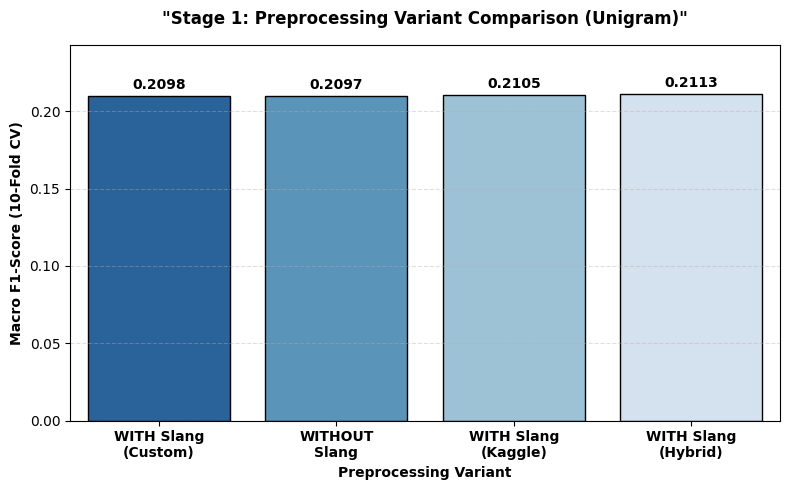


Best preprocessing variant:  (0.2113)


In [21]:
# --- 2.18 Preprocessing Variant Tournament ---

print("Stage 1: Preprocessing Variant Tournament")
print("Evaluation using Unigram (1,1) without SMOTE under 10-Fold Cross-Validation.\n")

vec_params = {
    'min_df': 2,
    'max_df': 0.90,
    'sublinear_tf': True,
    'strip_accents': 'unicode'
}

tournament_results = []
best_variant = ""
best_score = 0

for variant_name, data in preprocessing_results.items():
    X_data = data['X']
    y_data = data['y']
    
    # Build the evaluation pipeline.
    pipe_kamus = ImbPipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 1), **vec_params)),
        ('clf', MultinomialNB())
    ])
    
    print(f"Evaluating {variant_name}...")
    cv_scores = cross_val_score(pipe_kamus, X_data, y_data, cv=skf, scoring='f1_macro', n_jobs=-2)
    avg_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    tournament_results.append(
        {
            "Preprocessing Variant": variant_name,
            "Macro F1-Score (10-Fold CV)": avg_score,
            "Std Dev": std_score,
        }
    )

    print(f"Mean Macro F1-Score: {avg_score:.4f} (±{std_score:.4f})")
    
    if avg_score > best_score:
        best_score = avg_score
        best_preprocessing = variant_name

# --- VISUALISASI TAHAP 1 ---
df_tournament = pd.DataFrame(tournament_results)
print("\nTournament Results")
display(df_tournament)

plt.figure(figsize=(8, 5))
short_labels = [
    "WITH Slang\n(Custom)",
    "WITHOUT\nSlang",
    "WITH Slang\n(Kaggle)",
    "WITH Slang\n(Hybrid)",
]
ax1 = sns.barplot(x="Preprocessing Variant", y="Macro F1-Score (10-Fold CV)", data=df_tournament, palette='Blues_r', edgecolor='black', hue="Preprocessing Variant")
ax1.set_xticks(range(len(short_labels)))
ax1.set_xticklabels(short_labels, fontsize=10, fontweight='bold')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')

plt.ylim(0, max(df_tournament["Macro F1-Score (10-Fold CV)"]) * 1.15)

plt.title('"Stage 1: Preprocessing Variant Comparison (Unigram)"', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Macro F1-Score (10-Fold CV)', fontsize=10, fontweight='bold')
plt.xlabel("Preprocessing Variant", fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/preprocessing_variant_tournament.png', dpi=300)
plt.show()

print(
    f"\nBest preprocessing variant: "
    f"{best_variant} ({best_score:.4f})"
)


Vocabulary Analysis
Analyzing vocabulary size and lexical characteristics...


Vocabulary Statistics


,Preprocessing Variant,Vocabulary Size,Total Tokens,Macro F1-Score (10-Fold CV)
0,Variant 1: WITH Slang (Custom Dictionary),4565,239210,0.209845
1,Variant 2: WITHOUT Slang,4640,239093,0.209659
2,Variant 3: WITH Slang (Kaggle Dictionary),4247,227531,0.210515
3,Variant 4: WITH Slang (Hybrid Dictionary),4215,233610,0.211292


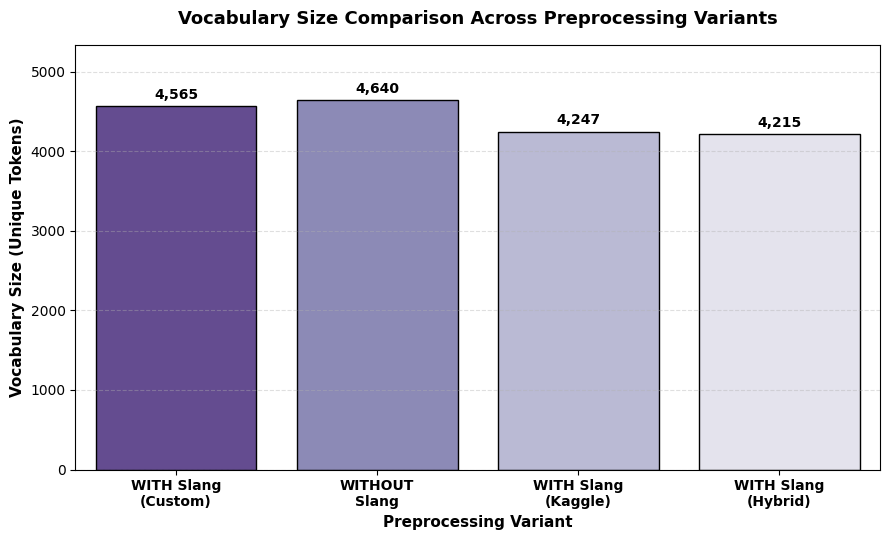


Figure saved as 'vocabulary_size_comparison.png'.


In [22]:
# --- 2.19 Vocabulary Analysis and Feature Space Audit ---

print("\nVocabulary Analysis")
print("Analyzing vocabulary size and lexical characteristics...\n")

vocabulary_analysis = []

for variant_name, data in preprocessing_results.items():
    X_data = data["X"]

    # Build a TF-IDF vectorizer to inspect the vocabulary.
    audit_vectorizer = TfidfVectorizer(
        ngram_range=(1, 1),
        **vec_params,
    )
    audit_vectorizer.fit(X_data)

    vocabulary_size = len(audit_vectorizer.get_feature_names_out())

    # Count the total number of remaining tokens.
    total_tokens = X_data.str.split().str.len().sum()

    # Retrieve the corresponding Macro F1-Score.
    macro_f1 = df_tournament.loc[
        df_tournament["Preprocessing Variant"] == variant_name,
        "Macro F1-Score (10-Fold CV)",
    ].iloc[0]

    vocabulary_analysis.append(
        {
            "Preprocessing Variant": variant_name,
            "Vocabulary Size": vocabulary_size,
            "Total Tokens": total_tokens,
            "Macro F1-Score (10-Fold CV)": macro_f1,
        }
    )

df_vocabulary = pd.DataFrame(vocabulary_analysis)

print("\nVocabulary Statistics")
display(df_vocabulary)

# --- Vocabulary Size Comparison ---

plt.figure(figsize=(9, 5.5))

ax_vocab = sns.barplot(
    x="Preprocessing Variant",
    y="Vocabulary Size",
    data=df_vocabulary,
    palette="Purples_r",
    hue="Preprocessing Variant",
    edgecolor="black",
)

ax_vocab.set_xticks(range(len(short_labels)))
ax_vocab.set_xticklabels(
    short_labels,
    fontsize=10,
    fontweight="bold",
)

for container in ax_vocab.containers:
    ax_vocab.bar_label(
        container,
        fmt="{:,.0f}",
        padding=3,
        fontsize=10,
        fontweight="bold",
    )

plt.ylim(0, df_vocabulary["Vocabulary Size"].max() * 1.15)

plt.title(
    "Vocabulary Size Comparison Across Preprocessing Variants",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

plt.ylabel(
    "Vocabulary Size (Unique Tokens)",
    fontsize=11,
    fontweight="bold",
)

plt.xlabel(
    "Preprocessing Variant",
    fontsize=11,
    fontweight="bold",
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig(
    "../images/vocabulary_size_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "\nFigure saved as "
    "'vocabulary_size_comparison.png'."
)

### 2. Feature Engineering (TF-IDF n-gram) and Class Imbalance Handling (SMOTE)

Stage 2: N-Gram Benchmark on the Best Preprocessing Variant (VARIANT 4: WITH SLANG (HYBRID DICTIONARY))
Evaluating n-gram configurations with SMOTE embedded inside the 10-fold cross-validation pipeline.

Evaluating Unigram (1,1)...
  Mean Macro F1: 0.3030 (±0.0062)
Evaluating Unigram + Bigram (1,2)...
  Mean Macro F1: 0.3384 (±0.0102)
Evaluating Unigram + Bigram + Trigram (1,3)...
  Mean Macro F1: 0.3359 (±0.0092)

N-Gram Benchmark Results


,N-Gram Configuration,Macro F1-Score (10-Fold CV),Std Dev
0,"Unigram (1,1)",0.302952,0.006150
1,"Unigram + Bigram (1,2)",0.338393,0.010236
2,"Unigram + Bigram + Trigram (1,3)",0.335893,0.009249


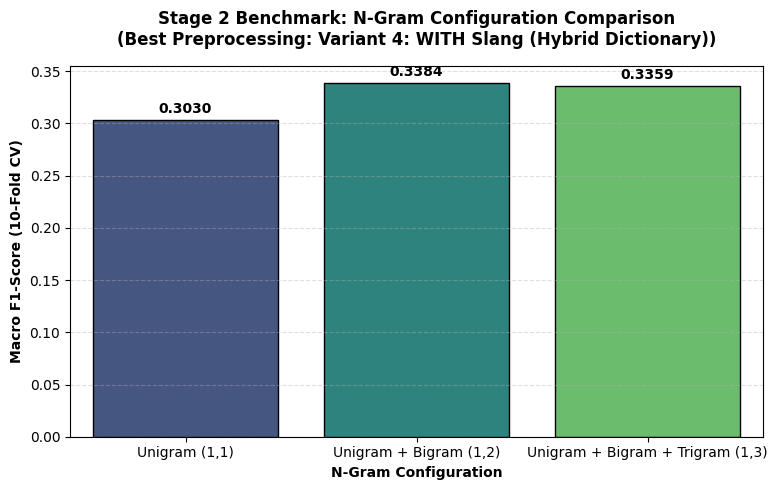


Best feature configuration: Unigram + Bigram (1,2) (Macro F1 = 0.3384)


In [23]:
# --- 2.20 N-Gram Configuration Benchmark ---

print(f"Stage 2: N-Gram Benchmark on the Best Preprocessing Variant ({best_preprocessing.upper()})")
print("Evaluating n-gram configurations with SMOTE embedded inside the 10-fold cross-validation pipeline.\n")

X_best = preprocessing_results[best_preprocessing]["X"]
y_best = preprocessing_results[best_preprocessing]["y"]

ngram_configs = {
    "Unigram (1,1)": (1, 1),
    "Unigram + Bigram (1,2)": (1, 2),
    "Unigram + Bigram + Trigram (1,3)": (1, 3),
}

ngram_results = []
best_macro_f1 = 0.0
best_ngram_name = ""

for config_name, ngram_range in ngram_configs.items():
    print(f"Evaluating {config_name}...")

    pipeline = ImbPipeline(
        [
            ("tfidf", TfidfVectorizer(ngram_range=ngram_range, **vec_params)),
            ("smote", SMOTE(random_state=42, k_neighbors=3)),
            ("classifier", MultinomialNB()),
        ]
    )

    cv_scores = cross_val_score(
        pipeline,
        X_best,
        y_best,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-2,
    )

    mean_score = cv_scores.mean()
    std_score = cv_scores.std()

    ngram_results.append(
        {
            "N-Gram Configuration": config_name,
            "Macro F1-Score (10-Fold CV)": mean_score,
            "Std Dev": std_score,
        }
    )

    print(f"  Mean Macro F1: {mean_score:.4f} (±{std_score:.4f})")

    if mean_score > best_macro_f1:
        best_macro_f1 = mean_score
        best_ngram_name = config_name

        best_model_config = {
            "preprocessing": best_preprocessing,
            "ngram_name": config_name,
            "ngram_range": ngram_range,
            "k_neighbors": 3,
        }

# --- Results Table ---

df_ngram = pd.DataFrame(ngram_results)

print("\nN-Gram Benchmark Results")
display(df_ngram)

# --- Visualization ---

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_ngram,
    x="N-Gram Configuration",
    y="Macro F1-Score (10-Fold CV)",
    hue="N-Gram Configuration",
    palette="viridis",
    edgecolor="black",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=10, fontweight="bold")

plt.title(
    f"Stage 2 Benchmark: N-Gram Configuration Comparison\n(Best Preprocessing: {best_preprocessing})",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

plt.xlabel("N-Gram Configuration", fontsize=10, fontweight="bold")
plt.ylabel("Macro F1-Score (10-Fold CV)", fontsize=10, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("../images/stage2_ngram_benchmark.png", dpi=300)
plt.show()

print(
    f"\nBest feature configuration: {best_ngram_name} "
    f"(Macro F1 = {best_macro_f1:.4f})"
)

### 3. Verifikasi Hasil Feature Engineering dan Penyeimbangan Kelas (SMOTE)

Memverifikasi konfigurasi terbaik hasil tahap rekayasa fitur dengan menampilkan ukuran vocabulary TF-IDF, dimensi matriks fitur, serta distribusi kelas setelah proses oversampling menggunakan SMOTE. Tahap ini memastikan bahwa fitur siap digunakan pada proses optimasi model.

In [24]:
# --- 2.21 Verify the Final Feature Representation (TF-IDF + SMOTE) ---

print("Verifying the final feature representation...\n")

# Dataset terbaik hasil turnamen preprocessing
best_preprocessing = best_model_config["preprocessing"]
X_best = preprocessing_results[best_preprocessing]["X"]
y_best = preprocessing_results[best_preprocessing]["y"]

# Inisialisasi TF-IDF menggunakan konfigurasi n-gram terbaik
final_vectorizer = TfidfVectorizer(
    ngram_range=best_model_config["ngram_range"],
    **vec_params,
)

X_tfidf = final_vectorizer.fit_transform(X_best)

# Terapkan SMOTE
final_smote = SMOTE(
    random_state=42,
    k_neighbors=best_model_config["k_neighbors"],
)

X_resampled, y_resampled = final_smote.fit_resample(
    X_tfidf,
    y_best,
)

print(f"Best preprocessing variant : {best_preprocessing}")
print(
    f"Best n-gram configuration : "
    f"{best_model_config['ngram_name']} "
    f"{best_model_config['ngram_range']}"
)
print(
    f"Vocabulary size           : "
    f"{len(final_vectorizer.get_feature_names_out()):,}"
)
print(f"Feature matrix shape      : {X_resampled.shape}")
print(f"Matrix type               : {type(X_resampled).__name__}")

print("-" * 60)
print("Class distribution after SMOTE:")

class_distribution = Counter(y_resampled)

for rating in sorted(class_distribution):
    print(f"Rating {rating}: {class_distribution[rating]:,}")

print("-" * 60)
print("Feature engineering verification completed.")
print("Dataset is ready for hyperparameter optimization.")

Verifying the final feature representation...

Best preprocessing variant : Variant 4: WITH Slang (Hybrid Dictionary)
Best n-gram configuration : Unigram + Bigram (1,2) (1, 2)
Vocabulary size           : 16,701
Feature matrix shape      : (137650, 16701)
Matrix type               : csr_matrix
------------------------------------------------------------
Class distribution after SMOTE:
Rating 1: 27,530
Rating 2: 27,530
Rating 3: 27,530
Rating 4: 27,530
Rating 5: 27,530
------------------------------------------------------------
Feature engineering verification completed.
Dataset is ready for hyperparameter optimization.


Generating class distribution comparison (Before vs After SMOTE)...


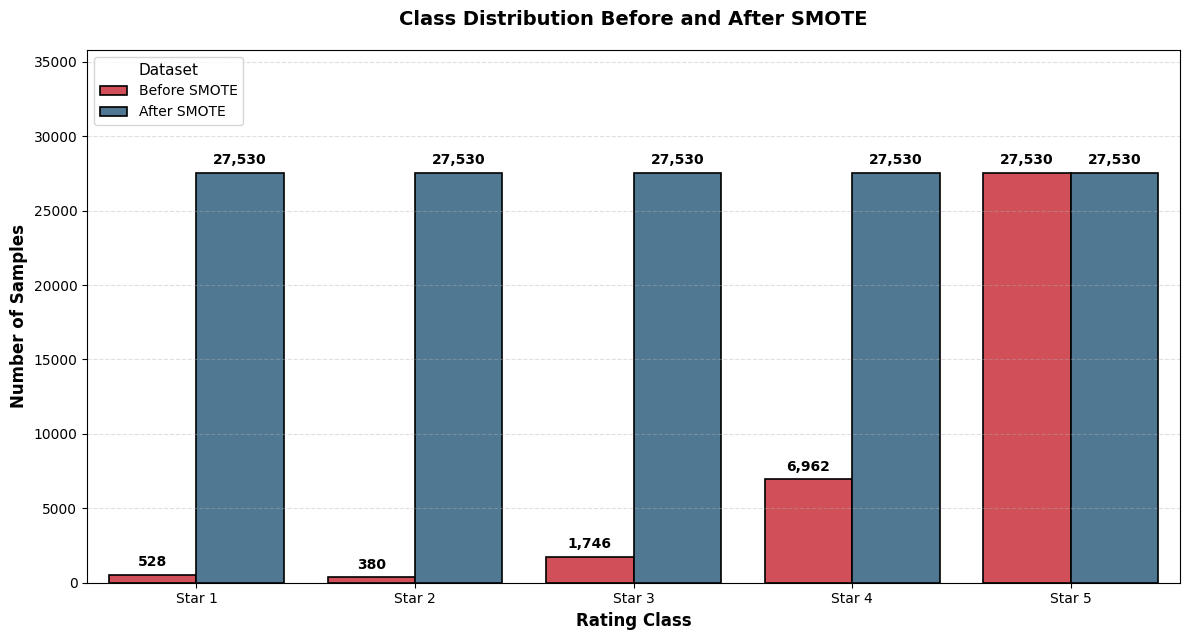


Figure saved as 'smote_class_distribution_comparison.png'
Samples before SMOTE : 37,146
Samples after SMOTE  : 137,650
Dataset growth       : 270.56%


In [25]:
# --- 2.22 Visualisasi Dampak SMOTE terhadap Distribusi Kelas ---

print("Generating class distribution comparison (Before vs After SMOTE)...")

# Distribusi kelas sebelum SMOTE
class_distribution_before = y_best.value_counts().sort_index()

# Distribusi kelas setelah SMOTE
class_distribution_after = (
    pd.Series(y_resampled)
    .value_counts()
    .sort_index()
)

# Menyiapkan DataFrame untuk visualisasi
smote_comparison = pd.DataFrame({
    "Rating": [f"Star {rating}" for rating in class_distribution_before.index] * 2,
    "Number of Samples": (
        list(class_distribution_before.values)
        + list(class_distribution_after.values)
    ),
    "Dataset": (
        ["Before SMOTE"] * len(class_distribution_before)
        + ["After SMOTE"] * len(class_distribution_after)
    ),
})

plt.figure(figsize=(12, 6.5))

ax = sns.barplot(
    data=smote_comparison,
    x="Rating",
    y="Number of Samples",
    hue="Dataset",
    palette=["#e63946", "#457b9d"],
    edgecolor="black",
    linewidth=1.2,
)

# Label jumlah sampel
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="{:,.0f}",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Class Distribution Before and After SMOTE",
    fontsize=14,
    fontweight="bold",
    pad=18,
)
plt.xlabel(
    "Rating Class",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel(
    "Number of Samples",
    fontsize=12,
    fontweight="bold",
)

plt.ylim(0, class_distribution_after.max() * 1.30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Dataset",
    loc="upper left",
    fontsize=10,
    title_fontsize=11,
)

plt.tight_layout()
plt.savefig(
    "../images/smote_class_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

growth_percentage = (
    (len(y_resampled) - len(y_best))
    / len(y_best)
    * 100
)

print(
    "\nFigure saved as "
    "'smote_class_distribution_comparison.png'"
)
print(f"Samples before SMOTE : {len(y_best):,}")
print(f"Samples after SMOTE  : {len(y_resampled):,}")
print(f"Dataset growth       : {growth_percentage:.2f}%")

# Stage 3: Hyperparameter Optimization

Stage 3: Hyperparameter Optimization
Selected Preprocessing : Variant 4: WITH Slang (Hybrid Dictionary)
Selected N-Gram Range : (1, 2)
Total Parameter Combinations: 34
Running Grid Search...
Fitting 10 folds for each of 34 candidates, totalling 340 fits

------------------------------------------------------------
Best Hyperparameters
------------------------------------------------------------
Optimal SMOTE k_neighbors : 3
Optimal Alpha Smoothing   : 0.1
Optimal Fit Prior         : True
Validation Score (Macro F1): 0.3450


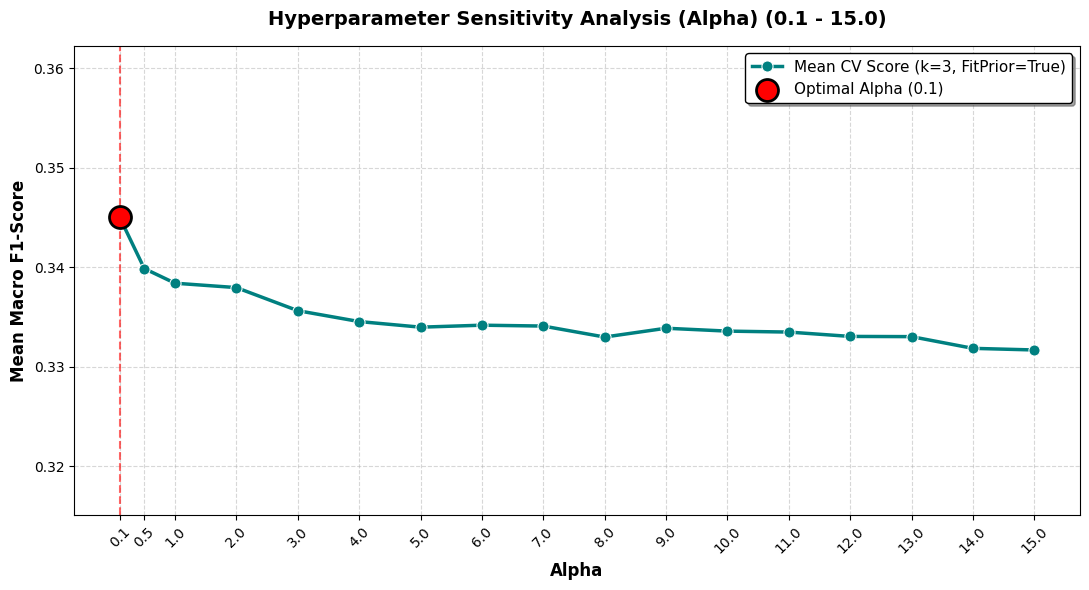


Image Saved: 'hyperparameter_alpha_sensitivity.png'


9711

In [26]:
# 3. Hyperparameter Optimization

# This stage aims to find the optimal parameters for SMOTE and 
# Multinomial Naive Bayes to reduce bias and improve model generalization.

print("Stage 3: Hyperparameter Optimization")

best_variant_name = best_model_config["preprocessing"]
best_ngram_range = best_model_config["ngram_range"]
best_k_neighbors = best_model_config["k_neighbors"]

X_best = preprocessing_results[best_variant_name]["X"]
y_best = preprocessing_results[best_variant_name]["y"]

print(f"Selected Preprocessing : {best_variant_name}")
print(f"Selected N-Gram Range : {best_ngram_range}")

# Build The Optimization Pipeline.
# All preprocessing steps are executed independently inside each cross-validation fold.
pipeline_tuning = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_ngram_range, **vec_params)),
    ('smote', SMOTE(random_state=42)),
    ('clf', MultinomialNB())
])

# Define The Hyperparameter Search Space.
# Multiple SMOTE and Multinomial Naive Bayes combinations are evaluated
# to identify the optimal model configuration.
k_neighbors_options = [3, 5, 7]
k_neighbors_options = [k for k in k_neighbors_options if k <= best_k_neighbors]

param_grid = {
    'smote__k_neighbors': k_neighbors_options, 
    'clf__alpha': [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0],
    'clf__fit_prior': [True, False]
}

total_combinations = len(param_grid['smote__k_neighbors']) * len(param_grid['clf__alpha']) * len(param_grid['clf__fit_prior'])

print(f"Total Parameter Combinations: {total_combinations}")

# Perform Grid Search Using Stratified 10-Fold Cross-Validation.
grid_search = GridSearchCV(
    estimator=pipeline_tuning,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-2,
    verbose=1
)

# Train And Evaluate All Parameter Combinations.
print("Running Grid Search...")
grid_search.fit(X_best, y_best)

# Extract The Best Configuration And Validation Score.
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "-" * 60)
print("Best Hyperparameters")
print("-" * 60)

print(f"Optimal SMOTE k_neighbors : {best_params['smote__k_neighbors']}")
print(f"Optimal Alpha Smoothing   : {best_params['clf__alpha']}")
print(f"Optimal Fit Prior         : {best_params['clf__fit_prior']}")
print(f"Validation Score (Macro F1): {best_score:.4f}")


# 3.1 Alpha Sensitivity Analysis
# Analyze The Impact Of MultinomialNB Alpha Values On Model Performance.
grid_results = pd.DataFrame(grid_search.cv_results_)

best_k = best_params['smote__k_neighbors']
best_prior = best_params['clf__fit_prior']

alpha_results = grid_results[
    (grid_results['param_smote__k_neighbors'] == best_k) &
    (grid_results['param_clf__fit_prior'] == best_prior)
].copy()
alpha_results['param_clf__alpha'] = alpha_results['param_clf__alpha'].astype(float)
alpha_results = alpha_results.sort_values(by='param_clf__alpha')

plt.figure(figsize=(11, 6))

# Plot Alpha Sensitivity Curve.
sns.lineplot(data=alpha_results, x='param_clf__alpha', y='mean_test_score', marker='o', color='teal', linewidth=2.5, markersize=8, label=f'Mean CV Score (k={best_k}, FitPrior={best_prior})')

# Highlight The Optimal Alpha Value From Grid Search.
plt.scatter(best_params['clf__alpha'], best_score, color='red', s=250, zorder=5, edgecolor='black', linewidth=2, label=f"Optimal Alpha ({best_params['clf__alpha']})")
plt.axvline(x=best_params['clf__alpha'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

plt.title('Hyperparameter Sensitivity Analysis (Alpha) (0.1 - 15.0)', fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Alpha', fontsize=12, fontweight='bold')
plt.ylabel('Mean Macro F1-Score', fontsize=12, fontweight='bold')

plt.ylim(min(alpha_results['mean_test_score']) * 0.95, best_score * 1.05)
plt.xticks(param_grid['clf__alpha'], rotation=45)
plt.tick_params(axis='both', labelsize=10)
plt.legend(fontsize=11, loc='best', frameon=True, shadow=True, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


# Save Visualization Output.
plt.savefig('../images/hyperparameter_alpha_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nImage Saved: 'hyperparameter_alpha_sensitivity.png'")

gc.collect()

# Stage 4: Final Evaluation & Scenario Comparison

Starting Multi-Scenario Analysis (5 Full 10-Fold CV Evaluations)

[1/5] Running Scenario 1: Baseline (Raw Text Condition)...

[2/5] Running Scenario 2: Preprocessing Integration (Variant 4: WITH Slang (Hybrid Dictionary))...

[3/5] Running Scenario 3: N-Gram Feature Integration (Unigram + Bigram (1,2))...

[4/5] Running Scenario 4: SMOTE Resampling Integration...

[5/5] Retrieving Scenario 5: Hyperparameter Optimization Result...

FINAL RESEARCH COMPARISON RESULTS


,Scenario,Macro F1 (CV),Std Dev
0,1. Baseline (Raw),0.170439,0.000386
1,2. Preprocessing,0.211292,0.009510
2,3. N-Gram Features,0.201075,0.003383
3,4. SMOTE Resampling,0.338393,0.010236
4,5. Final Tuning,0.344999,0.010424


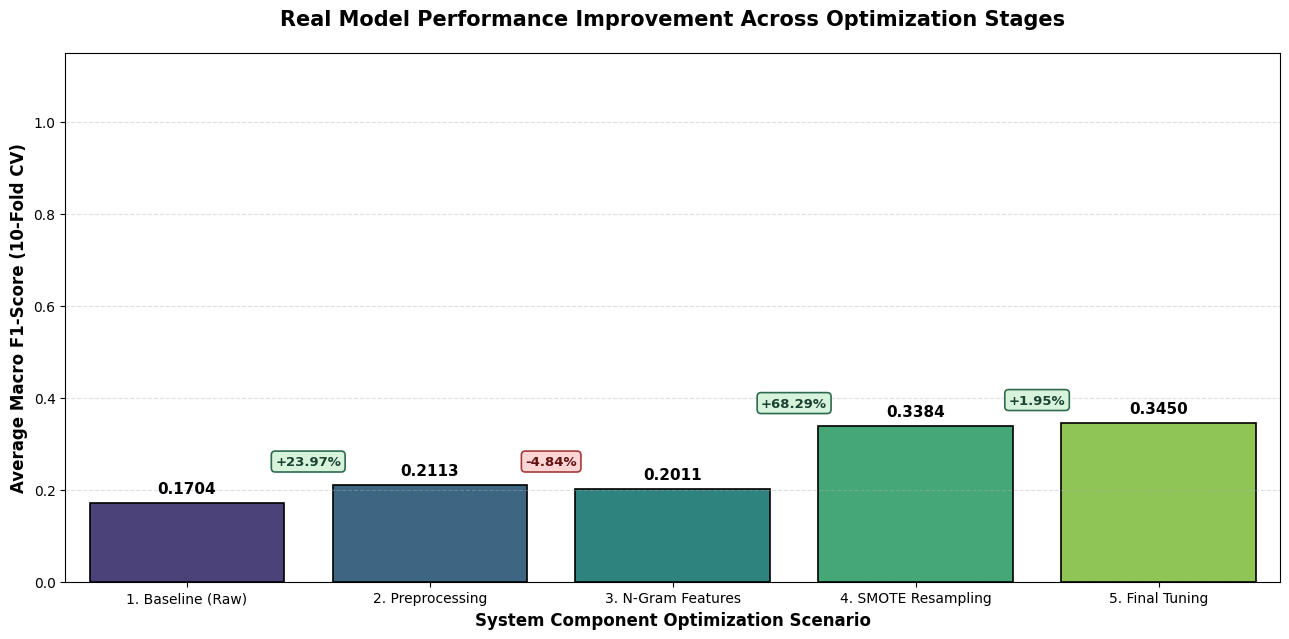

In [27]:
# ==============================================================================
# STAGE 4: FINAL EVALUATION & SCENARIO COMPARISON
# ==============================================================================

# This stage evaluates the contribution of each system component through
# an ablation study, starting from the baseline model until the final optimized model.

# Select the best preprocessing configuration from previous optimization stage.
best_variant_name = best_model_config['preprocessing']

X_best = preprocessing_results[best_variant_name]['X']
y_best = preprocessing_results[best_variant_name]['y']

comparison_results = []

print("Starting Multi-Scenario Analysis (5 Full 10-Fold CV Evaluations)")


# 4.1 Ablation Study Evaluation

# Scenario 1: Baseline Model
# Using raw text, unigram features, no class balancing, and default parameters.
print("\n[1/5] Running Scenario 1: Baseline (Raw Text Condition)...")
X_raw_synchronized = X_raw_all.loc[y_best.index]

pipe_1 = ImbPipeline([
    ('tfidf', TfidfVectorizer(tokenizer=lambda x: str(x).split(), token_pattern=None, lowercase=False)),
    ('clf', MultinomialNB())
])

cv_scores_1 = cross_val_score(pipe_1, X_raw_synchronized, y_best, cv=skf, scoring='f1_macro', n_jobs=-2)

comparison_results.append({'Scenario': '1. Baseline (Raw)', 'Macro F1 (CV)': cv_scores_1.mean(), 'Std Dev': cv_scores_1.std()})


# Scenario 2: Impact Of Preprocessing
# Adding slang normalization and stemming using unigram features.
print(f"\n[2/5] Running Scenario 2: Preprocessing Integration ({best_variant_name})...")

pipe_2 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), **vec_params)),
    ('clf', MultinomialNB())
])

cv_scores_2 = cross_val_score(pipe_2, X_best, y_best, cv=skf, scoring='f1_macro', n_jobs=-2)

comparison_results.append({'Scenario': '2. Preprocessing', 'Macro F1 (CV)': cv_scores_2.mean(), 'Std Dev': cv_scores_2.std()})


# Scenario 3: Impact Of N-Gram Features
# Using the optimal N-Gram configuration obtained from previous evaluation.
print(f"\n[3/5] Running Scenario 3: N-Gram Feature Integration ({best_model_config['ngram_name']})...")

pipe_3 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_model_config['ngram_range'], **vec_params)),
    ('clf', MultinomialNB())
])

cv_scores_3 = cross_val_score(pipe_3, X_best, y_best, cv=skf, scoring='f1_macro', n_jobs=-2)

comparison_results.append({'Scenario': '3. N-Gram Features', 'Macro F1 (CV)': cv_scores_3.mean(), 'Std Dev': cv_scores_3.std()})


# Scenario 4: Impact Of Class Resampling
# Handling class imbalance using SMOTE with optimized neighbor configuration.
print("\n[4/5] Running Scenario 4: SMOTE Resampling Integration...")

pipe_4 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_model_config['ngram_range'], **vec_params)),
    ('smote', SMOTE(random_state=42, k_neighbors=best_model_config['k_neighbors'])),
    ('clf', MultinomialNB())
])

cv_scores_4 = cross_val_score(pipe_4, X_best, y_best, cv=skf, scoring='f1_macro', n_jobs=-2)

comparison_results.append({'Scenario': '4. SMOTE Resampling', 'Macro F1 (CV)': cv_scores_4.mean(), 'Std Dev': cv_scores_4.std()})


# Scenario 5: Final Hyperparameter Optimization
# Using the best GridSearchCV result without repeating the same CV process.
print("\n[5/5] Retrieving Scenario 5: Hyperparameter Optimization Result...")

best_cv_score = grid_search.best_score_
best_cv_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

comparison_results.append({'Scenario': '5. Final Tuning', 'Macro F1 (CV)': best_cv_score, 'Std Dev': best_cv_std})


# 4.2 Final Performance Comparison Visualization
print("\n" + "=" * 65)
print("FINAL RESEARCH COMPARISON RESULTS")
print("=" * 65)

df_comparison = pd.DataFrame(comparison_results)
display(df_comparison)


plt.figure(figsize=(13, 6.5))

ax = sns.barplot(x='Scenario', y='Macro F1 (CV)', data=df_comparison, palette='viridis', hue='Scenario', legend=False, edgecolor='black', linewidth=1.2)


for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')


# Calculate And Display Marginal Performance Improvement Between Stages.

for i in range(1, len(df_comparison)):
    previous_value = df_comparison.iloc[i - 1]['Macro F1 (CV)']
    current_value = df_comparison.iloc[i]['Macro F1 (CV)']
    change = ((current_value - previous_value) / previous_value) * 100

    if abs(change) > 0.001:
        color = '#1b4332' if change > 0 else '#641111'
        face_color = '#d8f3dc' if change > 0 else '#fcd5d5'
        edge_color = '#2d6a4f' if change > 0 else '#a63a3a'
        sign = '+' if change > 0 else ''

        x_position = (i - 1 + i) / 2
        y_position = max(previous_value, current_value) + 0.05

        ax.text(x_position, y_position, f'{sign}{change:.2f}%', ha='center', va='center', fontsize=9.5, color=color, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor=face_color, edgecolor=edge_color, linewidth=1.2))


plt.title('Real Model Performance Improvement Across Optimization Stages', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Average Macro F1-Score (10-Fold CV)', fontsize=12, fontweight='bold')
plt.xlabel('System Component Optimization Scenario', fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()


plt.savefig('../images/ablation_study_5_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# 4.3 Vocabulary Size Analysis Across Scenarios

print("Text Feature Dimension Transformation Analysis")

# Retrieve the optimal N-Gram configuration from previous evaluation.
best_ngram_name = best_model_config['ngram_name']

# Initialize Baseline and Optimized Vectorizers to measure vocabulary dimensions.
baseline_vectorizer = TfidfVectorizer(tokenizer=lambda x: str(x).split(), token_pattern=None, lowercase=False)
baseline_vectorizer.fit(X_raw_synchronized)

optimized_vectorizer = TfidfVectorizer(ngram_range=best_model_config['ngram_range'], **vec_params)
optimized_vectorizer.fit(X_best)


baseline_vocabulary_size = len(baseline_vectorizer.get_feature_names_out())
optimized_vocabulary_size = len(optimized_vectorizer.get_feature_names_out())

print(f"Selected N-Gram Configuration       : {best_ngram_name}")
print(f"Baseline Vocabulary Size            : {baseline_vocabulary_size:,} features")
print(f"Optimized Vocabulary Size           : {optimized_vocabulary_size:,} features")

# Calculate vocabulary dimension reduction efficiency.
vocabulary_reduction = baseline_vocabulary_size - optimized_vocabulary_size
reduction_percentage = (vocabulary_reduction / baseline_vocabulary_size) * 100

print(f"Vocabulary Dimension Efficiency     : Reduced {vocabulary_reduction:,} features ({reduction_percentage:.2f}%)")

Text Feature Dimension Transformation Analysis
Selected N-Gram Configuration       : Unigram + Bigram (1,2)
Baseline Vocabulary Size            : 35,158 features
Optimized Vocabulary Size           : 16,701 features
Vocabulary Dimension Efficiency     : Reduced 18,457 features (52.50%)


N-Gram Experiment Results


,N-Gram Configuration,Vocabulary Size,Macro F1-Score (10-Fold CV),Std Dev
0,"Unigram (1,1)",4215,0.302952,0.006150
1,"Unigram + Bigram (1,2)",16701,0.338393,0.010236
2,"Unigram + Bigram + Trigram (1,3)",27929,0.335893,0.009249



---------------------------------------------------------------------------
LINGUISTIC FEATURE EXPANSION ANALYSIS
---------------------------------------------------------------------------
Optimal N-Gram Configuration : Unigram + Bigram (1,2)
Feature Dimension Increase   : +12,486 features (+296.23%)
Macro F1 Improvement         : +0.0354 (+11.70%)
---------------------------------------------------------------------------


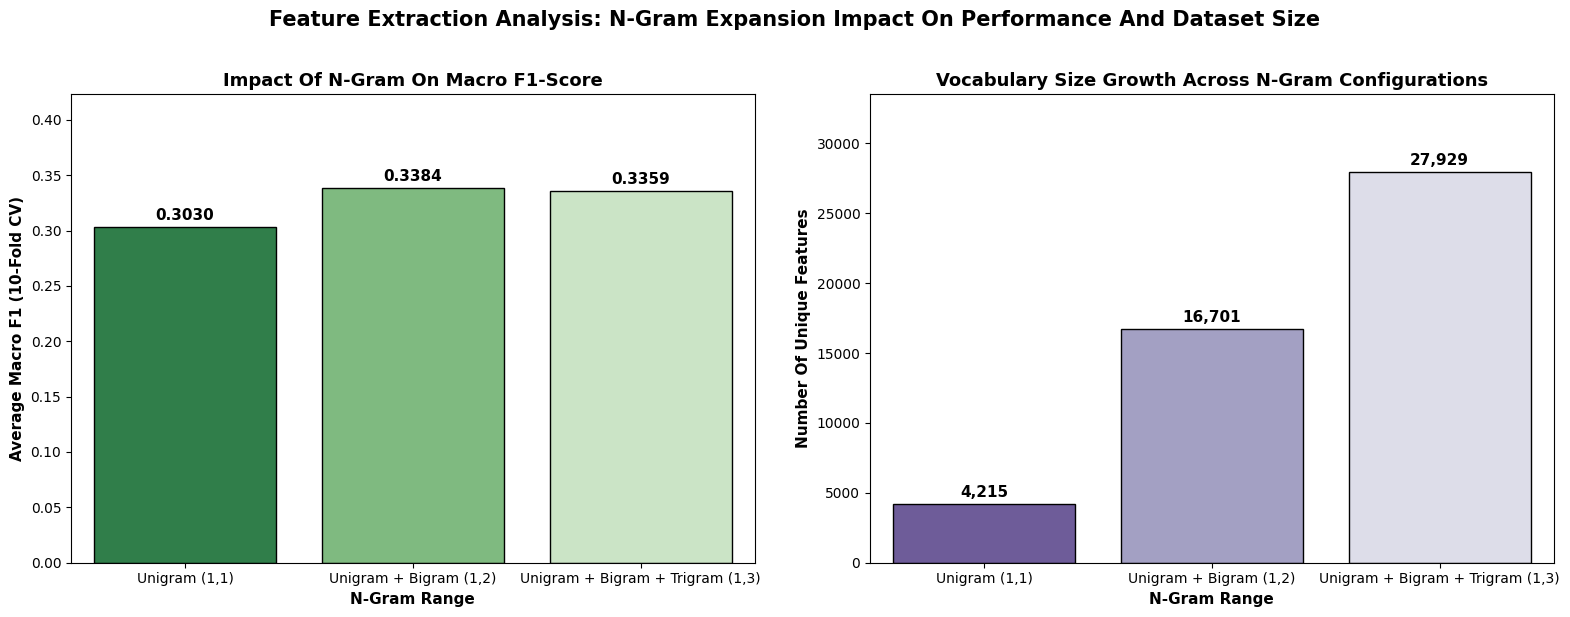


---------------------------------------------------------------------------
ANALYSIS SUMMARY
---------------------------------------------------------------------------
1. The 'Unigram + Bigram (1,2)' configuration captures additional contextual
   information from e-commerce review phrases that may be missed by Unigram features.
2. Although feature dimensions increased by 296.23%, Multinomial Naive Bayes
   maintained efficient execution without significant curse of dimensionality issues.
---------------------------------------------------------------------------


In [29]:
# 4.4 Comparative Analysis: N-Gram Impact After SMOTE (Full CV)

# Retrieve results from comprehensive N-Gram evaluation.
best_variant_name = best_model_config['preprocessing']
df_ngram_ablation = df_ngram.copy()

# Calculate Vocabulary Size For Each N-Gram Configuration.
vocabulary_sizes = {}
for ngram_name, ngram_range in ngram_configs.items():
    vectorizer = TfidfVectorizer(ngram_range=ngram_range,**vec_params)
    vectorizer.fit(preprocessing_results[best_variant_name]["X"])
    vocabulary_sizes[ngram_name] = len(vectorizer.get_feature_names_out())

# Add Vocabulary Size Information To Evaluation Results.
df_ngram_ablation['Vocabulary Size'] = df_ngram_ablation['N-Gram Configuration'].map(vocabulary_sizes)

df_ngram_ablation = df_ngram_ablation.reset_index(drop=True)

print("N-Gram Experiment Results")

display(df_ngram_ablation[['N-Gram Configuration', 'Vocabulary Size', 'Macro F1-Score (10-Fold CV)', 'Std Dev']])

# Identify Unigram Baseline Configuration.
unigram_row = df_ngram_ablation[df_ngram_ablation['N-Gram Configuration'].str.contains('Unigram \(1,1\)|Unigram', case=False)]

if unigram_row.empty:
    unigram_result = df_ngram_ablation.iloc[0]
else:
    unigram_result = unigram_row.iloc[0]

# Retrieve Optimal N-Gram Configuration Result.
optimal_ngram_result = df_ngram_ablation[
    df_ngram_ablation['N-Gram Configuration'] == best_model_config['ngram_name']
].iloc[0]

# Calculate Vocabulary Expansion And Performance Improvement.
vocabulary_increase = optimal_ngram_result['Vocabulary Size'] - unigram_result['Vocabulary Size']
vocabulary_increase_percentage = (vocabulary_increase / unigram_result['Vocabulary Size']) * 100

f1_improvement = optimal_ngram_result['Macro F1-Score (10-Fold CV)'] - unigram_result['Macro F1-Score (10-Fold CV)']

f1_improvement_percentage = (f1_improvement / unigram_result['Macro F1-Score (10-Fold CV)']) * 100

print("\n" + "-" * 75)
print("LINGUISTIC FEATURE EXPANSION ANALYSIS")
print("-" * 75)

print(f"Optimal N-Gram Configuration : {best_model_config['ngram_name']}")
print(f"Feature Dimension Increase   : +{vocabulary_increase:,} features ({vocabulary_increase_percentage:+.2f}%)")
print(f"Macro F1 Improvement         : {f1_improvement:+.4f} ({f1_improvement_percentage:+.2f}%)")

print("-" * 75)

# 4.5 N-Gram Comparison Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Performance Comparison Based On Macro F1-Score.
sns.barplot(x='N-Gram Configuration', y='Macro F1-Score (10-Fold CV)', data=df_ngram_ablation, palette='Greens_r', ax=axes[0], hue='N-Gram Configuration', legend=False, edgecolor='black')

axes[0].set_title('Impact Of N-Gram On Macro F1-Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Macro F1 (10-Fold CV)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('N-Gram Range', fontsize=11, fontweight='bold')

axes[0].set_ylim(0, max(df_ngram_ablation['Macro F1-Score (10-Fold CV)']) * 1.25)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')

# Vocabulary Growth Comparison.
sns.barplot(x='N-Gram Configuration', y='Vocabulary Size', data=df_ngram_ablation, palette='Purples_r', ax=axes[1], hue='N-Gram Configuration', legend=False, edgecolor='black')

axes[1].set_title('Vocabulary Size Growth Across N-Gram Configurations', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number Of Unique Features', fontsize=11, fontweight='bold')
axes[1].set_xlabel('N-Gram Range', fontsize=11, fontweight='bold')

axes[1].set_ylim(0, max(df_ngram_ablation['Vocabulary Size']) * 1.20)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', padding=3, fontsize=11, fontweight='bold')


plt.suptitle('Feature Extraction Analysis: N-Gram Expansion Impact On Performance And Dataset Size', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/ngram_ablation_analysis_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Analysis Summary.
print("\n" + "-" * 75)
print("ANALYSIS SUMMARY")
print("-" * 75)

print(f"1. The '{best_model_config['ngram_name']}' configuration captures additional contextual")
print("   information from e-commerce review phrases that may be missed by Unigram features.")

print(f"2. Although feature dimensions increased by {vocabulary_increase_percentage:.2f}%, Multinomial Naive Bayes")
print("   maintained efficient execution without significant curse of dimensionality issues.")

print("-" * 75)

<h3>Confusion Matrix Visualization</h3>

This visualization shows how the Final Model classifies each rating category, especially minority classes. It also compares prediction errors between the Baseline Model and the Final Optimized Model.

In [30]:
print("Creating Evaluation Variables For Confusion Matrix")

# Retrieve Actual Labels And Optimized Preprocessing Data.
y_actual_rating = preprocessing_results[best_model_config['preprocessing']]['y']
X_best = preprocessing_results[best_model_config['preprocessing']]['X']

# Generate Baseline Model Predictions Using Scenario 1 Configuration.
X_raw_synchronized = X_raw_all.loc[y_actual_rating.index]
pipeline_baseline = ImbPipeline([
    ('tfidf', TfidfVectorizer(tokenizer=lambda x: str(x).split(), token_pattern=None, lowercase=False)),
    ('clf', MultinomialNB())
])

pred_baseline_cv = cross_val_predict(pipeline_baseline, X_raw_synchronized, y_actual_rating, cv=skf, n_jobs=-2)
print("- Baseline Predictions Successfully Generated.")

# Generate Final Model Predictions Using The Best GridSearchCV Estimator.
pred_final_cv = cross_val_predict(grid_search.best_estimator_, X_best, y_actual_rating, cv=skf, n_jobs=-2)
print("- Final Model Predictions Successfully Generated.")

Creating Evaluation Variables For Confusion Matrix
- Baseline Predictions Successfully Generated.
- Final Model Predictions Successfully Generated.


Generating Confusion Matrix And Cross-Fold Evaluation Report


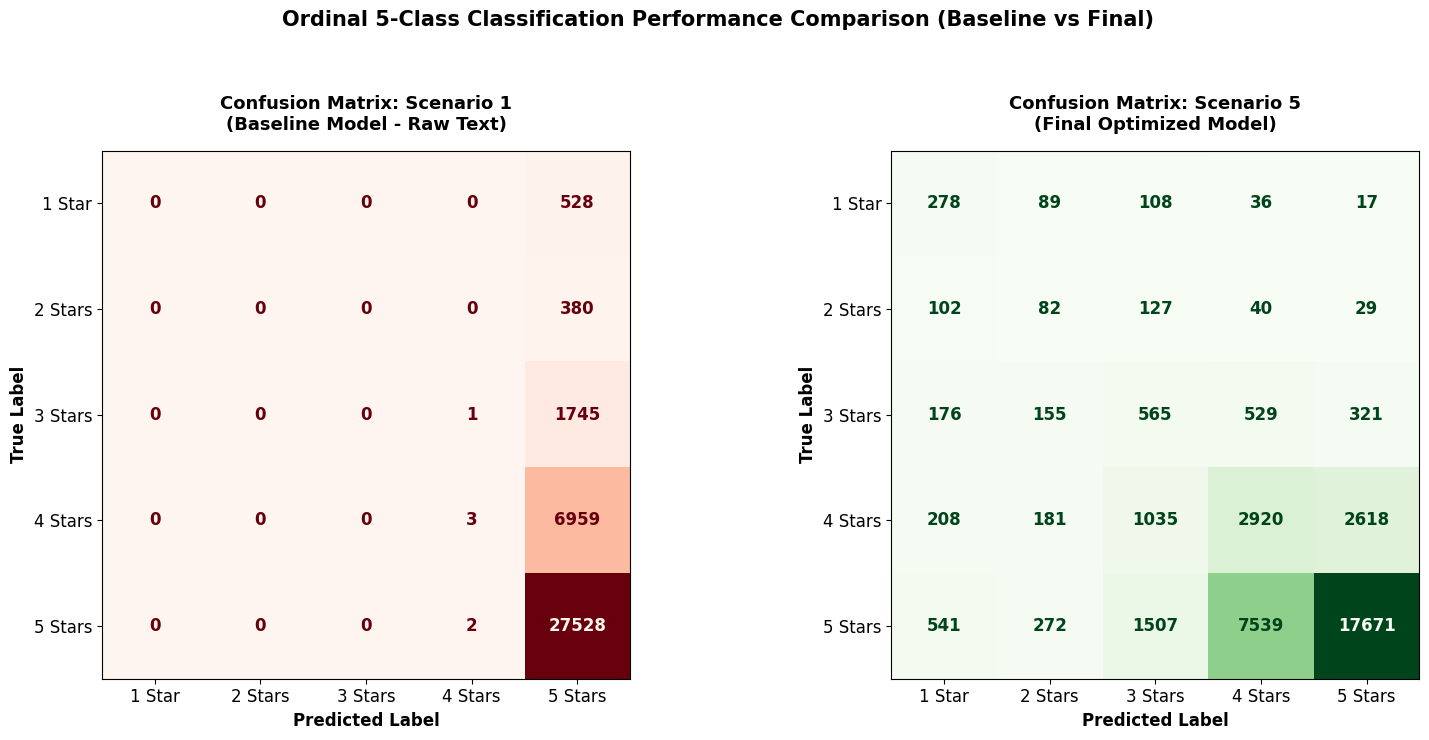


---------------------------------------------------------------------------
Classification Report: Baseline System (Full CV)
---------------------------------------------------------------------------
              precision    recall  f1-score   support

      1 Star       0.00      0.00      0.00       528
     2 Stars       0.00      0.00      0.00       380
     3 Stars       0.00      0.00      0.00      1746
     4 Stars       0.50      0.00      0.00      6962
     5 Stars       0.74      1.00      0.85     27530

    accuracy                           0.74     37146
   macro avg       0.25      0.20      0.17     37146
weighted avg       0.64      0.74      0.63     37146


---------------------------------------------------------------------------
Classification Report: Final Optimized System (Full CV)
---------------------------------------------------------------------------
              precision    recall  f1-score   support

      1 Star       0.21      0.53      0.30  

In [31]:
# 4.6 Confusion Matrix Comparison And Classification Report (Full 10-Fold CV)
print("Generating Confusion Matrix And Cross-Fold Evaluation Report")

# Define Ordinal Rating Label Order (1 To 5 Stars).
labels_rating = [1, 2, 3, 4, 5]
display_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

# Create Side-By-Side Visualization Canvas.
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Scenario 1: Baseline Model Without SMOTE.
# Calculate Accumulated Confusion Matrix Across All Folds.
cm_baseline = confusion_matrix(y_actual_rating, pred_baseline_cv, labels=labels_rating)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=display_labels)
disp_baseline.plot(cmap='Reds', ax=ax[0], colorbar=False)

ax[0].set_title('Confusion Matrix: Scenario 1\n(Baseline Model - Raw Text)', fontsize=13, fontweight='bold', pad=15)
ax[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
ax[0].tick_params(axis='both', labelsize=12)

for text in disp_baseline.text_.flat:
    text.set_fontsize(12)
    text.set_fontweight('bold')

# Scenario 5: Final Optimized Model With SMOTE And Hyperparameter Tuning.
# Calculate Final Confusion Matrix From Optimized System.
cm_final = confusion_matrix(y_actual_rating, pred_final_cv, labels=labels_rating)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=display_labels)
disp_final.plot(cmap='Greens', ax=ax[1], colorbar=False)


ax[1].set_title('Confusion Matrix: Scenario 5\n(Final Optimized Model)', fontsize=13, fontweight='bold', pad=15)
ax[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
ax[1].tick_params(axis='both', labelsize=12)

for text in disp_final.text_.flat:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.suptitle('Ordinal 5-Class Classification Performance Comparison (Baseline vs Final)', fontsize=15, fontweight='bold', y=1.05)
plt.subplots_adjust(wspace=0.25)
plt.tight_layout()

# Save High-Resolution Visualization Output.
plt.savefig('../images/confusion_matrix_comparison_final.png', dpi=300, bbox_inches='tight')

plt.show()

# Generate Classification Reports.
print("\n" + "-" * 75)
print("Classification Report: Baseline System (Full CV)")
print("-" * 75)

print(classification_report(y_actual_rating, pred_baseline_cv, target_names=display_labels, zero_division=0))

print("\n" + "-" * 75)
print("Classification Report: Final Optimized System (Full CV)")
print("-" * 75)

print(classification_report(y_actual_rating, pred_final_cv, target_names=display_labels, zero_division=0))

**<h3>Feature Importance Analysis</h3>**
Most Influential Features

Feature Importance Analysis: Most Influential Features Across 5 Rating Classes

Selected N-Gram Configuration : Unigram + Bigram (1,2)
Total Feature Vocabulary Size : 16,701 tokens
Classification Target Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (Ordinal Rating)

Top 10 Important Features For Rating 1:
    1. tidak                     (log_prob: -3.3216)
    2. barang                    (log_prob: -4.2980)
    3. tidak sesuai              (log_prob: -4.3287)
    4. barang tidak              (log_prob: -4.3357)
    5. kecewa                    (log_prob: -4.5653)
    6. kirim                     (log_prob: -4.5927)
    7. tidak fungsi              (log_prob: -4.7546)
    8. pakai                     (log_prob: -4.7634)
    9. rusak                     (log_prob: -4.7999)
   10. nya                       (log_prob: -5.0577)
--------------------------------------------------
Top 10 Important Features For Rating 2:
    1. tidak                     (log_prob

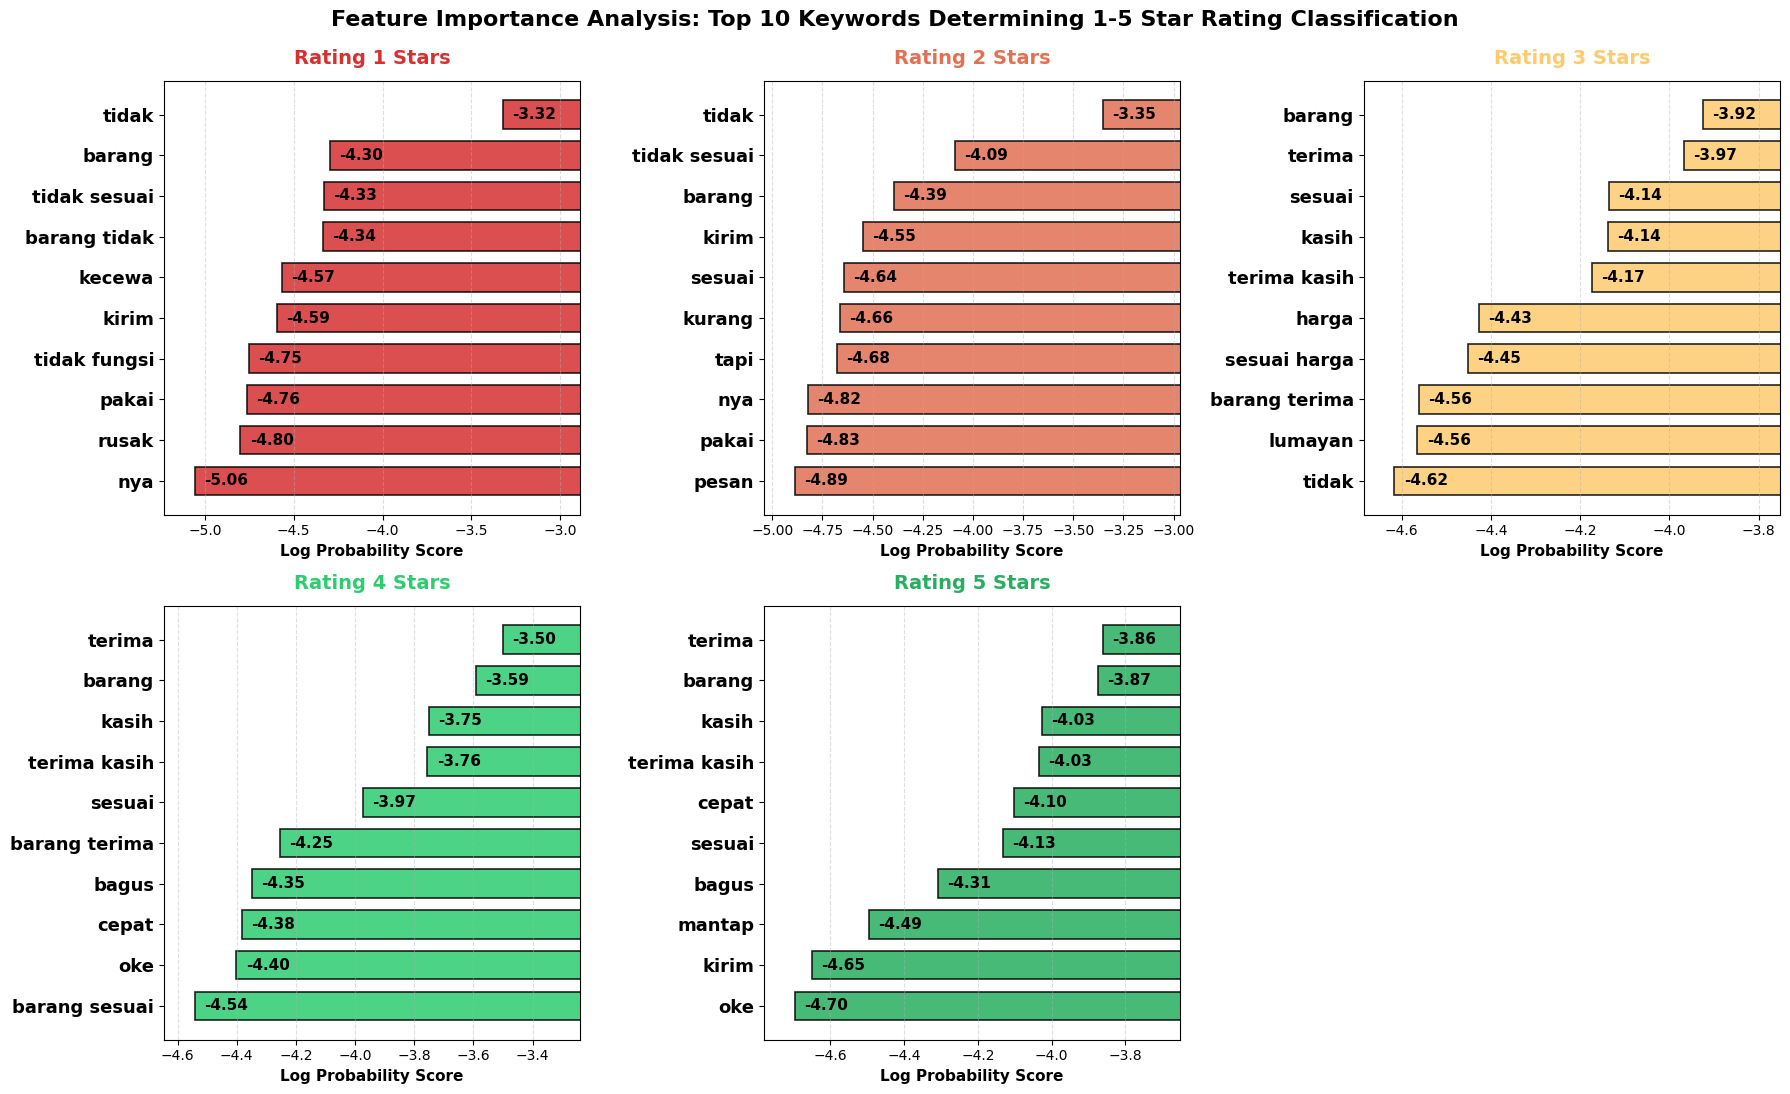


Visualization Saved: 'images/feature_importance_5rating_bertumpuk.png'


In [32]:
# 4.6 Feature Importance Analysis

print("Feature Importance Analysis: Most Influential Features Across 5 Rating Classes\n")

# Extract TF-IDF Vectorizer And MultinomialNB Model From The Best Pipeline.
best_model_pipeline = grid_search.best_estimator_
vectorizer = best_model_pipeline.named_steps['tfidf']
model = best_model_pipeline.named_steps['clf']

# Retrieve Feature Names From Combined N-Gram Vocabulary.
feature_names = vectorizer.get_feature_names_out()

# Retrieve Log Probability Matrix From MultinomialNB.
log_probability = model.feature_log_prob_

# Define Ordinal Rating Classes.
class_labels = sorted(list(y_best.unique()))

print(f"Selected N-Gram Configuration : {best_model_config['ngram_name']}")
print(f"Total Feature Vocabulary Size : {len(feature_names):,} tokens")
print(f"Classification Target Classes : {class_labels} (Ordinal Rating)\n")

# Extract Top Features For Each Rating Class.
top_n_features = 10
top_features = {}

for i, label in enumerate(class_labels):
    # Sort Features Based On Highest Log Probability For Each Class.
    top_indices = log_probability[i].argsort()[-top_n_features:][::-1]
    class_top_features = [(feature_names[idx], log_probability[i][idx]) for idx in top_indices]
    top_features[label] = class_top_features

    print(f"Top {top_n_features} Important Features For Rating {label}:")
    for rank, (word, score) in enumerate(class_top_features, 1):
        print(f"   {rank:2d}. {word:25s} (log_prob: {score:.4f})")

    print("-" * 50)


# Feature Importance Visualization (2 Rows x 3 Columns Layout)
print("\nGenerating Feature Importance Visualization")

# Create Grid Layout For Five Rating Classes.
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=False)

axes_flat = axes.flatten()

# Define Color Mapping For Each Rating Class.
colors_map = {
    1: '#d63031',
    2: '#e17055',
    3: '#fdcb6e',
    4: '#2ecc71',
    5: '#27ae60'
}

for i, label in enumerate(class_labels):
    current_axis = axes_flat[i]

    words = [word for word, _ in top_features[label]]
    scores = [score for _, score in top_features[label]]

    # Create Horizontal Bar Chart.
    current_axis.barh(words, scores, height=0.70, color=colors_map[label], alpha=0.85, edgecolor='black', linewidth=1.2)

    # Adjust X-Axis Limits Dynamically.
    min_score = min(scores)
    max_score = max(scores)
    score_range = max_score - min_score if (max_score - min_score) != 0 else 1

    current_axis.set_xlim(min_score - score_range * 0.1, max_score + score_range * 0.25)
    current_axis.set_xlabel('Log Probability Score', fontsize=11, fontweight='bold')
    current_axis.set_title(f'Rating {label} Stars', fontsize=14, fontweight='bold', pad=12, color=colors_map[label])
    current_axis.invert_yaxis()

    # Improve Text Readability For Academic Publication.
    current_axis.tick_params(axis='y', labelsize=13)
    current_axis.tick_params(axis='x', labelsize=10)

    for tick in current_axis.get_yticklabels():
        tick.set_fontweight('bold')

    current_axis.grid(axis='x', linestyle='--', alpha=0.4)

    # Add Score Labels At The End Of Each Bar.
    for j, (word, score) in enumerate(zip(words, scores)):
        current_axis.text(score + score_range * 0.03, j, f'{score:.2f}', va='center', ha='left', fontsize=11, color='black', fontweight='bold')

# Hide Empty Sixth Plot Because Only Five Classes Exist.
axes_flat[5].axis('off')

plt.suptitle('Feature Importance Analysis: Top 10 Keywords Determining 1-5 Star Rating Classification', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()

# Save High-Resolution Visualization Output.
plt.savefig('../images/feature_importance_5rating_bertumpuk.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nVisualization Saved: 'images/feature_importance_5rating_bertumpuk.png'")

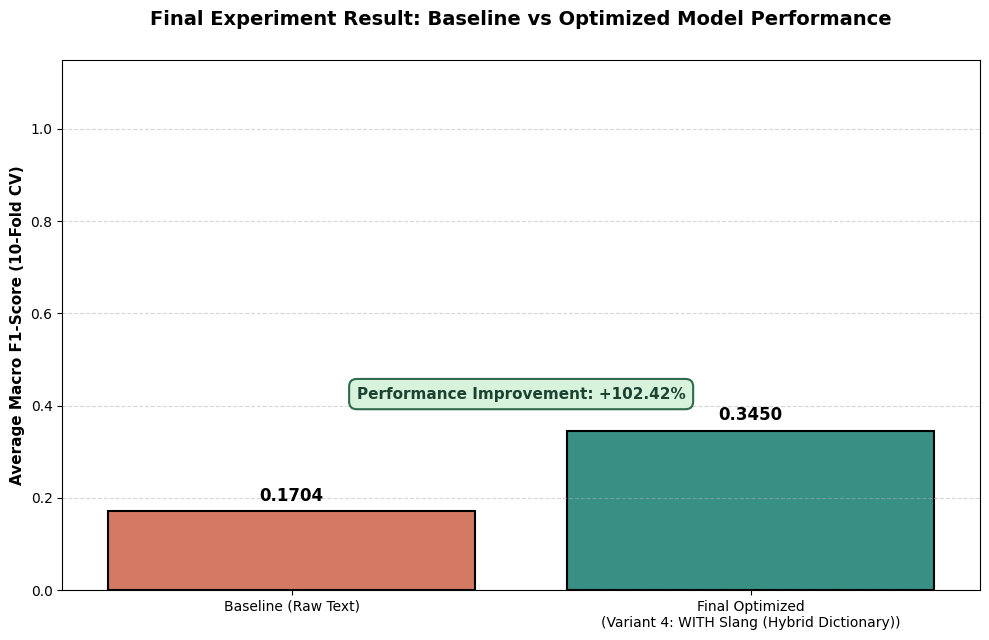

In [33]:
# 4.7 Final Performance Comparison

# Retrieve Actual Macro F1 Scores From Ablation Study Results.
baseline_f1 = df_comparison.iloc[0]['Macro F1 (CV)']
final_f1 = df_comparison.iloc[4]['Macro F1 (CV)']

# Calculate Relative Performance Improvement.
relative_improvement = ((final_f1 - baseline_f1) / baseline_f1) * 100

# Prepare Data For Final Performance Visualization.
df_final_comparison = pd.DataFrame({
    'Model': ['Baseline (Raw Text)', f'Final Optimized\n({best_variant_name})'],
    'Macro F1-Score': [baseline_f1, final_f1]
})

fig, ax = plt.subplots(figsize=(10, 6.5))

# Create Performance Comparison Bar Chart.
sns.barplot(
    x='Model',
    y='Macro F1-Score',
    data=df_final_comparison,
    palette=['#e76f51', '#2a9d8f'],
    ax=ax,
    hue='Model',
    legend=False,
    edgecolor='black',
    linewidth=1.5
)

# Display Score Values Above Each Bar.
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=12, fontweight='bold', color='black')

# Add Performance Improvement Badge Between Two Bars.
improvement_sign = "+" if relative_improvement > 0 else ""
badge_position = max(baseline_f1, final_f1) + 0.08

ax.text(
    0.5,
    badge_position,
    f'Performance Improvement: {improvement_sign}{relative_improvement:.2f}%',
    ha='center',
    va='center',
    fontsize=11,
    color='#1b4332',
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#d8f3dc', edgecolor='#2d6a4f', linewidth=1.5)
)

# Final Visualization Formatting.
ax.set_title(
    'Final Experiment Result: Baseline vs Optimized Model Performance',
    fontsize=14,
    fontweight='bold',
    pad=25
)

ax.set_ylabel('Average Macro F1-Score (10-Fold CV)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save Final Performance Comparison Visualization.
plt.savefig('../images/final_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Calculating Dynamic Data Retention During Preprocessing
-> Final Clean Dataset Size : 37,146 rows
-> Removed Noise Data       : 3,461 rows
-> Data Retention Rate      : 91.48%


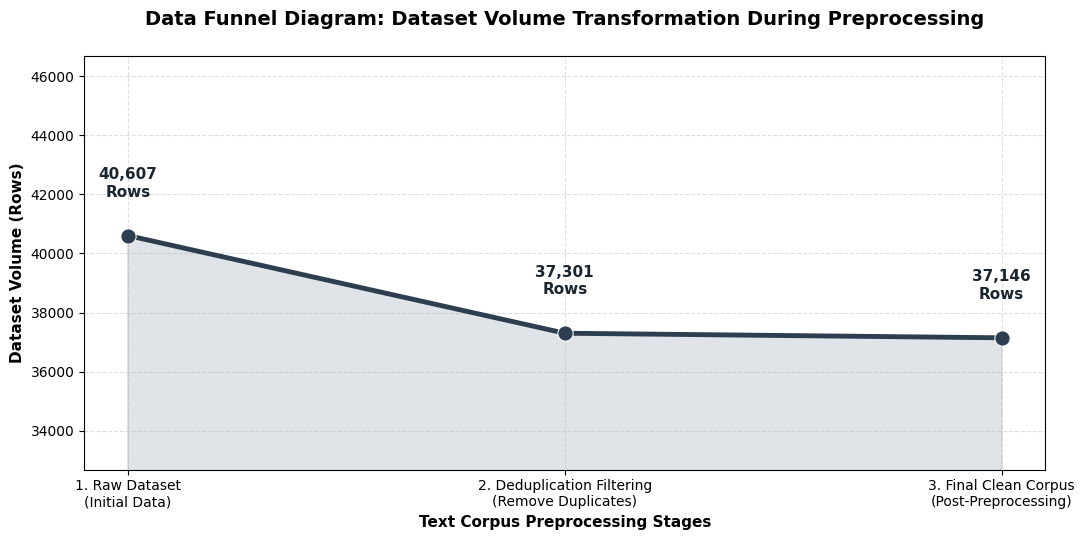


Visualization saved: 'preprocessing_data_funnel_complete.png'


In [ ]:
# 4.8 Data Funnel Diagram: Dataset Transformation From Raw To Post-Processing

print("Calculating Dynamic Data Retention During Preprocessing")

try:
    # Retrieve Raw Dataset Size.
    if 'df' in globals() and len(globals()['df']) > 40000:
        raw_count = len(globals()['df'])
    elif 'df_scraped' in globals():
        raw_count = len(df_scraped)
    else:
        raw_count = 40607

    # Retrieve Dataset Size After Deduplication.
    dedup_count = initial_len if 'initial_len' in locals() or 'initial_len' in globals() else 37301

    # Retrieve Final Clean Dataset Size After Preprocessing.
    clean_count = len(y_best)

    row_counts = [raw_count, dedup_count, clean_count]

except NameError:
    row_counts = [40607, 37301, 37146]

stage_labels = [
    '1. Raw Dataset\n(Initial Data)',
    '2. Deduplication Filtering\n(Remove Duplicates)',
    '3. Final Clean Corpus\n(Post-Preprocessing)'
]

df_funnel = pd.DataFrame({
    'Stage': stage_labels,
    'Dataset Size': row_counts
})

# Calculate Data Retention Efficiency.

retention_percentage = (row_counts[-1] / row_counts[0]) * 100
removed_data = row_counts[0] - row_counts[-1]

print(f"-> Final Clean Dataset Size : {row_counts[-1]:,} rows")
print(f"-> Removed Noise Data       : {removed_data:,} rows")
print(f"-> Data Retention Rate      : {retention_percentage:.2f}%")

# Visualize Dataset Reduction Trend.

plt.figure(figsize=(11, 5.5))

ax = sns.lineplot(x='Stage', y='Dataset Size', data=df_funnel, marker='o', markersize=11, color='#2c3e50', linewidth=3.5, sort=False)

plt.fill_between(stage_labels, row_counts, color='#34495e', alpha=0.15)

for x, y in enumerate(row_counts):
    ax.text(x, y + (max(row_counts) * 0.03), f'{y:,}\nRows', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1a252f')

plt.title('Data Funnel Diagram: Dataset Volume Transformation During Preprocessing', fontsize=14, fontweight='bold', pad=22)
plt.ylabel('Dataset Volume (Rows)', fontsize=11, fontweight='bold')
plt.xlabel('Text Corpus Preprocessing Stages', fontsize=11, fontweight='bold')

plt.ylim(min(row_counts) * 0.88, max(row_counts) * 1.15)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig('../images/preprocessing_data_funnel_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved: 'preprocessing_data_funnel_complete.png'")

In [35]:
# Deployment: Save Model Assets

print("Saving Assets For Interactive Deployment")

best_deploy_pipeline = grid_search.best_estimator_

joblib.dump(best_deploy_pipeline, '../models/multinomial_nb.pkl')
joblib.dump(SLANG_DICT_HYBRID, '../resources/hybrid_slang_dictionary.pkl')

print("Successfully Saved: 'multinomial_nb.pkl'")
print("Successfully Saved: 'hybrid_slang_dictionary.pkl'")

Saving Assets For Interactive Deployment
Successfully Saved: 'multinomial_nb.pkl'
Successfully Saved: 'hybrid_slang_dictionary.pkl'
